# 6 · Théorie de l'information — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch06_information/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 6.1 à 6.6 | vérifier tes exercices papier ✏️ | ✏️ | ★ à ★★ | |
| A | 6.12 | self_information et entropy | 🔨 | ★ | 15 |
|  | 6.13 | Distributions de caractères et de mots | 🔨 | ★★ | 20 |
|  | 6.14 | Qui a l'entropie par lettre la plus haute : Holmes ou Verne ? | 🔮 | ★★ | 15 |
|  | 6.15 | Fréquences des lettres en anglais et en français | 🎨 | ★★ | 20 |
| B | 6.16 | cross_entropy, kl_divergence et js_divergence | 🔨 | ★★ | 25 |
|  | 6.17 | La cross-entropy infinie : la lettre qui manque | 🐛 | ★★ | 20 |
|  | 6.18 | Coder le français avec le code de l'anglais, et l'inverse | 🔬 | ★★ | 25 |
|  | 6.19 | scipy.stats.entropy et un vrai compresseur (zlib) | 📦 | ★★ | 20 |
| C | 6.20 | Lire une courbe de loss : nats, bits et perplexité | 📈 | ★★ | 20 |
|  | 6.21 | Mesurer avant d'optimiser : compter des caractères vite | 🛠️ | ★★ | 20 |
|  | 6.22 | perplexity et log_loss | 🔨 | ★★ | 30 |
| D | 6.23 | Huffman : construire, encoder, décoder | 🔨 | ★★★ | 45 |
|  | 6.24 | Compresser Holmes : code fixe, Morse, Huffman et entropie | 🔬 | ★★★ | 30 |
|  | 6.25 | Le code de Huffman de Holmes pour envoyer Verne | 🔮 | ★★★ | 30 |
|  | 6.26 | Le contexte local réduit la surprise : les bigrammes | 🔬 | ★★★ | 40 |
|  | 6.27 | Passer sous la barre de Huffman lettre à lettre | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Calculer la surprise d'un événement et l'entropie d'une distribution, en bits et en nats.
- Mesurer le coût d'un code fait pour une autre distribution : cross-entropy et divergence KL.
- Construire un code de Huffman, et comparer code fixe, Morse, Huffman, entropie et vrai compresseur.
- Relier cross-entropy, log loss et perplexité, et mesurer ce que le contexte fait gagner.

**Rappel express.** Surprise $I(p) = -\log_2 p$ ; entropie $H(p) = -\sum_i p_i \log_2 p_i$, entre 0 et $\log_2 n$ ; cross-entropy $H(p, q) = -\sum_i p_i \log_2 q_i \ge H(p)$ ; $\mathrm{KL}(p \,\|\, q) = H(p, q) - H(p) \ge 0$, non symétrique ; 1 nat $= \frac{1}{\ln 2} \approx 1{,}443$ bit ; perplexité $= e^{\text{loss en nats}} = 2^{\text{loss en bits}}$. En Python : `np.log2`, `np.log`, `collections.Counter`, `heapq`, `scipy.stats.entropy`, `zlib.compress`, `timeit.repeat`.

## Partie 0 · Vérifier tes exercices papier (✏️ 6.1 à 6.6)

Fais d'abord les exercices ✏️ de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse ici : **la valeur** que tu as trouvée (par exemple `42`, `0.125`, `[1, 2, 3]` ou `True`), pas l'expression Python, sinon tu ne vérifies rien. En Python, le séparateur décimal est un **point** (`0.125`) ; `0,125` sans guillemets serait un couple de deux nombres. Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les exercices ∂ 6.7 et 6.8 se corrigent avec `05_solutions.md`.

In [2]:
# The paper exercises only use the numbers of their statements (02_exercices.md)
import math

import numpy as np


def entropy_bits(p):
    """Entropy in bits, with 0 log 0 = 0."""
    return -sum(x * math.log2(x) for x in p if x > 0)


def cross_entropy_bits(p, q):
    """Cross-entropy H(p, q) in bits (q > 0 wherever p > 0)."""
    return -sum(x * math.log2(y) for x, y in zip(p, q) if x > 0)


MORSE = dict(a=".-", b="-...", c="-.-.", d="-..", e=".", f="..-.", g="--.", h="....", i="..", j=".---",
             k="-.-", l=".-..", m="--", n="-.", o="---", p=".--.", q="--.-", r=".-.", s="...", t="-",
             u="..-", v="...-", w=".--", x="-..-", y="-.--", z="--..")
MESSAGE_64 = "sherlockholmes"                                  # 6.4: SHERLOCK HOLMES without the space
DOTS_64 = sum(len(MORSE[c]) for c in MESSAGE_64)
P_65, Q_65 = [0.8, 0.2], [0.5, 0.5]
WEATHER_66 = [0.40, 0.25, 0.15, 0.12, 0.08]                    # sun, clouds, rain, wind, snow
LENGTHS_66 = [1, 2, 3, 4, 4]                                   # their Huffman lengths
FRACTIONAL_CODE = ("un code de longueur fixe a un nombre ENTIER de chiffres binaires : log2 N arrondi à l'entier "
                   "SUPÉRIEUR, le plus petit k tel que 2 puissance k ≥ N")   # hint for a non-integer answer

**Ex 6.1 — Combien de bits pour une pièce, un dé, une lettre E ?**

In [3]:
wb.record("6.1a", -math.log2(0.5), decimals=3, mistakes={"c'est la probabilité : l'information vaut −log2 p": 0.5})
wb.record("6.1b", math.log2(6), decimals=3, mistakes={"c'est en nats (ln) : on demande des bits, avec log2": math.log(6),
                     "c'est le logarithme décimal : on demande log2": math.log10(6),
                     "c'est la probabilité : l'information vaut −log2 p": 1 / 6})
wb.record("6.1c", -math.log2(1 / 8), decimals=3, mistakes={"c'est la probabilité : l'information vaut −log2 p": 0.125})
wb.record("6.1d", -math.log2(1 / 1024), decimals=3, mistakes={"c'est la probabilité : l'information vaut −log2 p": 1 / 1024,
                     "1/1024 n'est pas 1/1000 : 1 024 est une puissance de 2, et son log2 tombe juste": math.log2(1000)})
wb.record("6.1e", -math.log2(1 / 8) - math.log2(1 / 1024), decimals=3, mistakes={"on multiplie les probabilités, donc on ADDITIONNE les informations": 3 * 10,
                     "1/1024 n'est pas 1/1000 : 1 024 est une puissance de 2, et son log2 tombe juste": 3 + math.log2(1000)})
wb.record("6.1f", 3 * math.log2(6), decimals=3, mistakes={"l'information dépend de la probabilité du résultat, pas des numéros des faces": math.log2(5) + math.log2(2) + math.log2(6),
                     "il y a trois dés indépendants : leurs probabilités se multiplient": math.log2(6)})
wb.record("6.1g", math.log(6), decimals=3, mistakes={"c'est en bits : les nats utilisent le logarithme népérien ln": math.log2(6),
                     "c'est le logarithme décimal : les nats utilisent ln": math.log10(6),
                     "tu as divisé par ln 2 : un bit vaut ln 2 nat, il faut multiplier": math.log2(6) / math.log(2)})
wb.record("6.1h", math.ceil(math.log2(6)), mistakes={"2 chiffres binaires ne donnent que 4 numéros : il en faut 6": 2,
           "c'est le nombre de faces : combien de chiffres binaires pour écrire 6 numéros différents ?": 6},
          fractional=FRACTIONAL_CODE)
wb.record("6.1i", -math.log2(0.1), decimals=3, mistakes={"c'est l'information de pile : face a la probabilité 0,1": -math.log2(0.9),
                     "tu as fait la moyenne des deux issues : on demande l'information de face seulement": entropy_bits([0.9, 0.1]),
                     "c'est la probabilité de face : l'information vaut −log2 p": 0.1})

WB_ANSWER {"decimals": 3, "hash": "775925ce49f786d23756cf270baad8601cd1af1eb4db2e125d66fcbaf9c05759", "hash_coarse": "819945ce2ec49e3772d8ac0b922e336dfe18d923eaf113a8a4c77559aea08d46", "id": "6.1a", "kind": "float", "magnitude": 0, "mistakes": {"72fb0a73dbc9a462e301044e8a613be90afbce70272cb5a9c30d6470bfd6238b": "c'est la probabilité : l'information vaut −log2 p"}, "sign": 1}
📝 Ex 6.1a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "31448f31ce6132aff3bab47cc4321e45dc51c444cf6cacf7dc0dc0c1058f87d9", "hash_coarse": "d8d6e9a2cd3e58cab9b0bee2482a7720ce35e4700edf6fedb59f9f93974efdb0", "id": "6.1b", "kind": "float", "magnitude": 0, "mistakes": {"1b8d8b6882b9e14d0e1a5d3bd0531cfc219514b1d7bc08e4372f85d40d9216f3": "c'est en nats (ln) : on demande des bits, avec log2", "7cc7a5ea7842b562ff4e8b0e2a8d70fedad1f92bcae0e235b7242effccbd00bb": "c'est la probabilité : l'information vaut −log2 p", "a0eae578e7c4bf88051b257d0681e84ea478e0c51554bf36f516ff6f9d816d19": "c'est le

**Ex 6.2 — Bits par mot : Seuss, Holmes et l'alphabet**

In [4]:
wb.record("6.2a", math.ceil(math.log2(64)), mistakes={"avec k chiffres binaires, on écrit 2 puissance k numéros, de 0 à 2 puissance k − 1 : quand N est exactement une puissance de 2, il n'en faut pas un de plus": 7},
          fractional=FRACTIONAL_CODE)
wb.record("6.2b", math.ceil(math.log2(65)), mistakes={"6 chiffres binaires ne donnent que 64 numéros : il en faut 65": 6},
          fractional=FRACTIONAL_CODE)
wb.record("6.2c", math.ceil(math.log2(236)), mistakes={"7 chiffres binaires ne donnent que 128 numéros : il en faut 236": 7},
          fractional=FRACTIONAL_CODE)
wb.record("6.2d", math.ceil(math.log2(7819)), mistakes={"12 chiffres binaires ne donnent que 4 096 numéros : il en faut 7 819": 12},
          fractional=FRACTIONAL_CODE)
wb.record("6.2e", math.ceil(math.log2(26 + 1 + 10)), mistakes={"5 chiffres binaires ne donnent que 32 numéros : as-tu compté tous les symboles (lettres, espace, chiffres), et arrondi log2 au-dessus ?": 5},
          fractional=FRACTIONAL_CODE)
wb.record("6.2f", math.ceil(math.log2(50257)), mistakes={"15 chiffres binaires ne donnent que 32 768 numéros : il en faut 50 257": 15},
          fractional=FRACTIONAL_CODE)
wb.record("6.2g", 105849 * math.ceil(math.log2(7819)), mistakes={"le code de d) utilise un nombre ENTIER de bits par mot : arrondis log2 au-dessus avant de multiplier": round(105849 * math.log2(7819))},
          fractional="le code de d) utilise un nombre entier de bits par mot : multiplie le nombre de mots par cette longueur entière")
wb.record("6.2h", 2 ** 14, mistakes={"c'est le plus grand NUMÉRO, en comptant à partir de 0 : combien de mots en tout ?": 2 ** 14 - 1,
           "14 bits ne veulent pas dire 14 mots : chaque bit double le nombre de numéros": 14})

WB_ANSWER {"fractional": "un code de longueur fixe a un nombre ENTIER de chiffres binaires : log2 N arrondi à l'entier SUPÉRIEUR, le plus petit k tel que 2 puissance k ≥ N", "hash": "92232862584c7a436dd82813b46a2a112383a4e765aad2ff4d5255df8636752a", "id": "6.2a", "kind": "int", "magnitude": 0, "mistakes": {"a03bfb03d2569c4c03175acaf028201684d15f10336974c09c831fc635cb75a8": "avec k chiffres binaires, on écrit 2 puissance k numéros, de 0 à 2 puissance k − 1 : quand N est exactement une puissance de 2, il n'en faut pas un de plus"}, "sign": 1}
📝 Ex 6.2a : réponse enregistrée (int).
WB_ANSWER {"fractional": "un code de longueur fixe a un nombre ENTIER de chiffres binaires : log2 N arrondi à l'entier SUPÉRIEUR, le plus petit k tel que 2 puissance k ≥ N", "hash": "b7140de359e79b09dcf3f58fb3e341cbb2764bfecae2b68478e9b6989738b867", "id": "6.2b", "kind": "int", "magnitude": 0, "mistakes": {"2690ff2656f492170cc596a8c12805bf7ecf99ea4e8fe673e8a5203dec991d41": "6 chiffres binaires ne donnent que 64

**Ex 6.3 — Entropie de quelques distributions**

In [5]:
wb.record("6.3a", entropy_bits([1 / 2, 1 / 4, 1 / 8, 1 / 8]), decimals=3, mistakes={"les issues ne sont pas équiprobables : pondère chaque surprise par sa probabilité": 2.0})
wb.record("6.3b", entropy_bits([1 / 8] * 8), decimals=2, mistakes={"c'est le nombre d'issues, pas une entropie : combien de bits pour désigner une issue parmi 8 équiprobables ?": 8})
wb.record("6.3c", entropy_bits([0.9, 0.1]), decimals=3, mistakes={"c'est en nats (ln) : on demande des bits": -(0.9 * math.log(0.9) + 0.1 * math.log(0.1)),
                     "tu n'as gardé que le terme de l'issue 0,1 : l'entropie somme sur toutes les issues": -0.1 * math.log2(0.1)})
wb.record("6.3d", entropy_bits([0.5, 0.5, 0.0]), decimals=3, mistakes={"une issue de probabilité 0 ne compte pas (0 log 0 = 0) : ce n'est pas une loi uniforme sur 3 issues": math.log2(3),
                     "ici, on demande l'entropie de [1/2 ; 1/2 ; 0] ; celle de [1 ; 0 ; 0] va dans ta copie": 0.0})
wb.record("6.3e", entropy_bits([1 / 2, 1 / 4, 1 / 8, 1 / 8]) * math.log(2), decimals=3, mistakes={"tu as divisé par ln 2 : pour passer des bits aux nats, on MULTIPLIE par ln 2": entropy_bits([1 / 2, 1 / 4, 1 / 8, 1 / 8]) / math.log(2),
                     "c'est encore en bits : multiplie par ln 2 pour avoir des nats": entropy_bits([1 / 2, 1 / 4, 1 / 8, 1 / 8])})
wb.record("6.3f", math.log2(4), decimals=2, mistakes={"c'est le nombre d'issues, pas une entropie : quelle distribution sur 4 issues est la plus imprévisible, et combien de bits vaut-elle ?": 4})
wb.record("6.3g", entropy_bits([0.5] + [0.1] * 5), decimals=3, mistakes={"c'est l'entropie d'un dé équilibré : celui-ci donne 6 une fois sur deux": math.log2(6),
                     "il y a cinq autres faces de probabilité 0,1, chacune avec son terme": entropy_bits([0.5, 0.1])})

WB_ANSWER {"decimals": 3, "hash": "639d465dba6f11a8bfd7f639bffb8fdc0932401ca23fcb6e95aaa0472a6a8762", "hash_coarse": "dc67f11f99d6a2a0b4da44e9e9340834ffc2325b8a296eec2478a4b400c85297", "id": "6.3a", "kind": "float", "magnitude": 0, "mistakes": {"bad38ecf6e59a2eac10f1b662e21df4182b0be61ca5d2820230b2b97618343ea": "les issues ne sont pas équiprobables : pondère chaque surprise par sa probabilité"}, "sign": 1}
📝 Ex 6.3a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "ce9f30492f783cf312a309a7502bf97ef444176e1adb4fbba13048c0738ad43a", "hash_coarse": "f6ae75df499d6f1e5cb4ddad8e3c582f070a3dacc200dfe1f98c1866319ed8c4", "id": "6.3b", "kind": "float", "magnitude": 0, "mistakes": {"89a00b86ef6600c2c4ccbaacc4432135b5a5c5c11be7314ad1cc7a09d66d7e27": "c'est le nombre d'issues, pas une entropie : combien de bits pour désigner une issue parmi 8 équiprobables ?"}, "sign": 1}
📝 Ex 6.3b : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "db4fbb

**Ex 6.4 — Morse contre code fixe : SHERLOCK HOLMES**

In [6]:
wb.record("6.4a", 5 * len(MESSAGE_64), mistakes={"l'espace entre les mots est ignoré : ne compte que les lettres": 5 * 15})
wb.record("6.4b", DOTS_64)
wb.record("6.4c", DOTS_64 / (5 * len(MESSAGE_64)), decimals=2, mistakes={"c'est le rapport a) / b) : on demande b) / a)": 5 * len(MESSAGE_64) / DOTS_64})
wb.record("6.4d", DOTS_64 + len(MESSAGE_64) - 1, mistakes={"un silence se place ENTRE deux lettres qui se suivent : n lettres n'ont que n − 1 intervalles": DOTS_64 + len(MESSAGE_64),
           "n'oublie pas le silence entre K et H : on ignore l'espace, mais il faut séparer les deux lettres": DOTS_64 + len(MESSAGE_64) - 2})
wb.record("6.4e", (DOTS_64 + len(MESSAGE_64) - 1) / (5 * len(MESSAGE_64)), decimals=2, mistakes={"tu as compté un silence de trop : n lettres qui se suivent n'ont que n − 1 intervalles": (DOTS_64 + len(MESSAGE_64)) / (5 * len(MESSAGE_64)),
                     "n'oublie pas le silence entre K et H : on ignore l'espace, mais il faut séparer les deux lettres": (DOTS_64 + len(MESSAGE_64) - 2) / (5 * len(MESSAGE_64)),
                     "tu n'as pas compté les silences : d) les ajoute aux points et aux traits": DOTS_64 / (5 * len(MESSAGE_64))})
wb.record("6.4f", 8, mistakes={"l'ordre compte : E puis I, ou I puis E, ce sont deux lectures": 5,
           "une seule lettre à la fois (E, I, S ou H) : on cherche aussi les suites de plusieurs lettres": 4})
wb.record("6.4g", False)

WB_ANSWER {"hash": "38d2fa87042cdac61412d7cc79ad75c9bcf6ac0bc6bd71aa8004fbe2466bec84", "id": "6.4a", "kind": "int", "magnitude": 1, "mistakes": {"1009713d1607682573296026d5c445a571a2fcbbbd6df80d4d0ac5ad6ef90073": "l'espace entre les mots est ignoré : ne compte que les lettres"}, "sign": 1}
📝 Ex 6.4a : réponse enregistrée (int).
WB_ANSWER {"hash": "6b4962c97dd7c18c0c32422fa920eae2ec427664a2a11ebee94d0934d5a08f19", "id": "6.4b", "kind": "int", "magnitude": 1, "sign": 1}
📝 Ex 6.4b : réponse enregistrée (int).
WB_ANSWER {"decimals": 2, "hash": "8f1920536299f166f69bf9d284d9ccf6c72b264cf55c202590228fd755b5098e", "hash_coarse": "202119c3957c2e9022d7dd17737b0fb4278b7fbcd91d0ca61ffa3a8dafbd7d6d", "id": "6.4c", "kind": "float", "magnitude": -1, "mistakes": {"2d78a856c9e032516e44e007fc94be3fa4452ac55a9472af4288d5a20b72dcde": "c'est le rapport a) / b) : on demande b) / a)"}, "sign": 1}
📝 Ex 6.4c : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"hash": "2489b90f17b905ff002e59da059deeffbb58d

**Ex 6.5 — Cross-entropy et KL dans les deux sens**

In [7]:
wb.record("6.5a", entropy_bits(P_65), decimals=3, mistakes={"c'est en nats (ln) : on demande des bits": -(0.8 * math.log(0.8) + 0.2 * math.log(0.2)),
                     "tu as calculé un écart entre p et q : H(p) ne fait intervenir que p, −Σ p_i log2 p_i": cross_entropy_bits(P_65, Q_65) - entropy_bits(P_65)})
wb.record("6.5b", cross_entropy_bits(P_65, Q_65), decimals=3, mistakes={"tu as pris les log de p : la cross-entropy prend les log de q, pondérés par p": entropy_bits(P_65),
                     "l'ordre compte : les poids viennent du premier argument, p, et les log du second, q": cross_entropy_bits(Q_65, P_65)})
wb.record("6.5c", cross_entropy_bits(P_65, Q_65) - entropy_bits(P_65), decimals=3, mistakes={"dans KL(p ‖ q), les poids viennent de p, le premier argument": cross_entropy_bits(Q_65, P_65) - entropy_bits(Q_65),
                     "le signe est inversé : KL(p ‖ q) = H(p, q) − H(p), toujours positive": entropy_bits(P_65) - cross_entropy_bits(P_65, Q_65),
                     "la KL est la DIFFÉRENCE H(p, q) − H(p), pas l'un de ses deux termes": entropy_bits(P_65)})
wb.record("6.5d", cross_entropy_bits(Q_65, P_65), decimals=3, mistakes={"l'ordre compte : ici, les poids viennent de q et les log de p": cross_entropy_bits(P_65, Q_65),
                     "c'est en nats (ln) : on demande des bits": -(0.5 * math.log(0.8) + 0.5 * math.log(0.2))})
wb.record("6.5e", cross_entropy_bits(Q_65, P_65) - entropy_bits(Q_65), decimals=3, mistakes={"dans KL(q ‖ p), les poids viennent de q, le premier argument": cross_entropy_bits(P_65, Q_65) - entropy_bits(P_65)})
wb.record("6.5f", True)
wb.record("6.5g", False)

WB_ANSWER {"decimals": 3, "hash": "388fcd8977b8fb757a71531caf00df2b22f2771ad3a61e852709691f5bcae8ef", "hash_coarse": "640550b4549842b3843cb1caeba89ca0374cd53d649dba64a79d2127472f05b5", "id": "6.5a", "kind": "float", "magnitude": -1, "mistakes": {"568baf2352b4a773a835d85766a98acfdd7764dbb541b0bd78496e83bc4ad8b9": "c'est en nats (ln) : on demande des bits", "fda073b5da1f6e4128e3480e66b8d32b2c08f753adbb1cc2bc47a68ef79d4d47": "tu as calculé un écart entre p et q : H(p) ne fait intervenir que p, −Σ p_i log2 p_i"}, "sign": 1}
📝 Ex 6.5a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "7216daa6ea5074cb0a1866706146a92bb63c2b4b73c844f53e43c9a6fb790173", "hash_coarse": "8cdbfc7ec4cbec3073eb4d257fc07947d908ef3f3ac9940b3df79458387e3d1f", "id": "6.5b", "kind": "float", "magnitude": 0, "mistakes": {"2981afd41842090cd7bef950df0cab4912007f53c1e518cdbecbbd33777a0c0b": "l'ordre compte : les poids viennent du premier argument, p, et les log du second, q", "a0abd4f8296f631c5

**Ex 6.6 — Un code de Huffman à la main**

In [8]:
wb.record("6.6a", math.ceil(math.log2(5)), mistakes={"2 chiffres binaires ne donnent que 4 numéros : il en faut 5": 2},
          fractional=FRACTIONAL_CODE)
wb.record("6.6b", LENGTHS_66, mistakes={"les deux symboles fusionnés en premier (les deux moins probables) ont toujours la même longueur": [1, 2, 3, 4, 5],
           "tu as donné les mots les plus courts aux états les plus rares : fusionne à chaque étape les deux groupes les MOINS probables, et garde l'ordre [soleil, nuages, pluie, vent, neige]": [4, 4, 3, 2, 1]})
wb.record("6.6c", sum(p * l for p, l in zip(WEATHER_66, LENGTHS_66)), decimals=3, mistakes={"tu as pris les surprises −log2 p_i au lieu des longueurs ℓ_i des mots de code": entropy_bits(WEATHER_66),
                     "c'est la moyenne des longueurs sans les pondérer par les probabilités": sum(LENGTHS_66) / 5})
wb.record("6.6d", entropy_bits(WEATHER_66), decimals=3, mistakes={"tu as pondéré des longueurs de mots de code : l'entropie pondère les surprises −log2 p_i": sum(p * l for p, l in zip(WEATHER_66, LENGTHS_66))})
wb.record("6.6e", sum(2.0 ** -l for l in LENGTHS_66), decimals=4, mistakes={"cette somme vient de longueurs fausses : les deux symboles fusionnés en premier ont toujours la même longueur": sum(2.0 ** -l for l in [1, 2, 3, 4, 5])})
wb.record("6.6f", 1 + 1 + 3 + 4 + 2, mistakes={"c'est avec le code fixe de a) : on demande le code de Huffman": 5 * 3},
          fractional="f) se calcule avec les longueurs entières des mots de code des cinq états du message")
wb.record("6.6g", sum(p * l for p, l in zip(WEATHER_66, LENGTHS_66)) / math.ceil(math.log2(5)), decimals=3, mistakes={"c'est le rapport a) / c) : on demande c) / a)": math.ceil(math.log2(5)) / sum(p * l for p, l in zip(WEATHER_66, LENGTHS_66))})

WB_ANSWER {"fractional": "un code de longueur fixe a un nombre ENTIER de chiffres binaires : log2 N arrondi à l'entier SUPÉRIEUR, le plus petit k tel que 2 puissance k ≥ N", "hash": "1bed01fda1bfd77cd08740660e6bae02a635550330342714675a86d37c3d9837", "id": "6.6a", "kind": "int", "magnitude": 0, "mistakes": {"40ada7a3ba26a19adbc45b2c679a0981ea496f9be9d9fe37830381dd4e897fe6": "2 chiffres binaires ne donnent que 4 numéros : il en faut 5"}, "sign": 1}
📝 Ex 6.6a : réponse enregistrée (int).
WB_ANSWER {"decimals": 0, "element_hashes": ["4dbae8d66be4c40abddc420d0a55011688bcf18398294b43e2ee2dbbe088b7ca", "ae0e522d46401d43e60bddbbeafecbbc76f997afadb5a5a057f042b49c22a526", "a97a81c49d18451ebf379831a8b6cc861958619457f2a92fc29c6542fbad1ccb", "e718d38cf0e5b71b7ee2990364c825ee1fc8cef1de2f081fd7d4bc3213eebdb7", "0947ec16e70be7c2c3b9c5d5793f286c04aed147f0ca0b89fa575c78eace7fde"], "hash": "8042c069c8202f74c374179cbdd357fc0ee23a1e5e6ba34c2be5604a77e2a283", "id": "6.6b", "integer": true, "kind": "array", 

## Partie A · Mesurer l'information : surprise, entropie, lettres de Holmes et de Verne

Fiche §6.2 à §6.7. Tu écris les premières fonctions de `mylearn.info` (la surprise, l'entropie, les distributions de lettres et de mots), tu prévois puis mesures l'entropie des lettres en anglais et en français, et tu dessines leurs fréquences. La cellule ci-dessous charge les outils de tout le notebook et les deux livres : exécute-la d'abord.

In [9]:
# Tools for the notebook exercises (parts A to D)
import collections
import itertools
import re
import timeit
import zlib

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def run_info_tests(keyword, impl="learner"):
    """Run the tests of mylearn.info selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", "tests/test_ch06_info.py", "-k", keyword, "-q",
               "-p", "no:cacheprovider", "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix("FAILED tests/test_ch06_info.py::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


LETTERS = "abcdefghijklmnopqrstuvwxyz"            # the 26 letters, without accents
LETTERS_FR = LETTERS + "àâæçéèêëîïôœùûüÿ"         # plus the accented letters and ligatures of French (42 in all)
INDEX = {letter: i for i, letter in enumerate(LETTERS)}   # 'a' -> 0, ..., 'z' -> 25


def words(text):
    """The words of a text, in lower case: runs of letters (accented ones included); the rest separates them."""
    return re.findall(r"[^\W\d_]+", text.lower())


def letters_only(text):
    """The letters a to z of a text, in lower case and in order (accented letters, spaces, punctuation dropped)."""
    return "".join(ch for ch in text.lower() if "a" <= ch <= "z")


holmes = wb.datasets.load_holmes()      # ch. 1: The Adventures of Sherlock Holmes (English), a str
verne = wb.datasets.load_verne()        # ch. 1: Le Tour du monde en quatre-vingts jours (French), a str
print(f"holmes: {len(holmes)} characters, {len(words(holmes))} words · verne: {len(verne)} characters, "
      f"{len(words(verne))} words")

holmes: 562203 characters, 105849 words · verne: 421336 characters, 72367 words


### Ex 6.12 — self_information et entropy 🔨 ★ ⏱️ 15 min
**Objectif :** écrire la surprise d'un événement et l'entropie d'une distribution, en bits ou en nats.  
**Prérequis :** Ex 6.1, Ex 6.3 · fiche §6.4, §6.7 · **Fil rouge :** synthétique · **mylearn :** `info.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/info.py` (créé par `python tools/start_chapter.py 6`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy et la bibliothèque standard sont permis (`np.asarray`, `np.log`, `np.log2`, `collections.Counter`, `heapq`…) ; SciPy, scikit-learn et PyTorch non : `scipy.stats.entropy`, `sklearn.metrics.log_loss` et `torch.nn.functional.cross_entropy` sont les **oracles** des tests. La cellule de vérification recharge ta librairie, affiche quelques valeurs, puis lance les tests de tes fonctions ; `python -m pytest tests/test_ch06_info.py -q` les lance tous dans un terminal.

Écris `self_information(p, base=2.0)` et `entropy(p, base=2.0)` (lis leurs docstrings) :
- deux petites fonctions d'aide te serviront dans tout le module : `_check_base(base)` lève une `ValueError` si la base n'est pas strictement positive ou vaut 1 ; `_as_distribution(p)` convertit `p` en tableau de flottants (`np.asarray(p, dtype=float)`) et lève une `ValueError` s'il n'est pas à une dimension, s'il est vide, s'il contient une valeur négative ou `NaN`, ou si sa somme s'écarte de 1 de plus de $10^{-6}$ (ne compare jamais une somme de flottants à 1 avec `==`) ;
- dans une base $b$ quelconque, $\log_b x = \frac{\ln x}{\ln b}$ (0B) ;
- `self_information` refuse une probabilité nulle, négative ou `NaN` (`~(p > 0)` attrape ces trois cas d'un coup), et une probabilité plus grande que 1 ; pour un `p` scalaire, elle renvoie un `float` Python, sinon un tableau de même forme ;
- `entropy` ignore les issues de probabilité nulle ($0 \log 0 = 0$) : garde seulement `p[p > 0]`, et renvoie un `float`.

La cellule de vérification affiche quelques valeurs, puis lance les tests des deux fonctions.

Dans tes notes : retrouve avec tes fonctions deux réponses de ✏️ 6.1 et deux de ✏️ 6.3. Que vaut l'entropie de $[0{,}9 ; 0{,}1]$ en nats (`base=np.e`) ?

In [10]:
surprise_12 = mylearn.info.self_information([1.0, 0.5, 0.125, 0.01])
print("surprise of p = 1, 0.5, 0.125, 0.01 (bits):", np.round(surprise_12, 4))
print("uniform on 4:", mylearn.info.entropy([0.25] * 4), "· certain:", mylearn.info.entropy([1.0, 0.0]),
      "· [0.9, 0.1] in nats:", round(mylearn.info.entropy([0.9, 0.1], base=np.e), 4))
print("6.1 b) and g):", round(mylearn.info.self_information(1 / 6), 3), round(mylearn.info.self_information(1 / 6, base=np.e), 3),
      "· 6.3 a) and c):", mylearn.info.entropy([1 / 2, 1 / 4, 1 / 8, 1 / 8]), round(mylearn.info.entropy([0.9, 0.1]), 3))
run_info_tests("test_self_information_ or test_entropy_", impl="ref")

surprise of p = 1, 0.5, 0.125, 0.01 (bits): [0.     1.     3.     6.6439]
uniform on 4: 2.0 · certain: 0.0 · [0.9, 0.1] in nats: 0.3251
6.1 b) and g): 2.585 1.792 · 6.3 a) and c): 1.75 0.469


pytest: 47 passed, 115 deselected in 1.94s


💡 L'entropie de $[0{,}9 ; 0{,}1]$ vaut 0,469 bit, soit 0,325 nat ($0{,}469 \times \ln 2$). Les deux fonctions d'aide servent ensuite à `cross_entropy`, `kl_divergence`, `js_divergence`, `huffman_code` et `log_loss` : une validation écrite une fois, testée une fois. La référence est dans `solutions/mylearn_ref/info.py` : lis-la **après** avoir réussi les tests.

### Ex 6.13 — Distributions de caractères et de mots 🔨 ★★ ⏱️ 20 min
**Objectif :** estimer la distribution des tokens d'un texte, sur un vocabulaire choisi, avec ou sans lissage.  
**Prérequis :** Ex 1.11 (fréquences des lettres) · Ex 6.12 · fiche §6.5, §6.6, §6.8 (lissage) · **Fil rouge :** Holmes/Verne · **mylearn :** `info.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/info.py`, mêmes règles qu'en 6.12 (NumPy et la bibliothèque standard permis, SciPy, scikit-learn et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `token_distribution(tokens, vocabulary=None, smoothing=0.0)` et `char_distribution(text, alphabet=None, lowercase=True, smoothing=0.0)` (lis leurs docstrings) :
- compte les tokens avec `collections.Counter` (0A), en **un seul passage** : `tokens` peut être un générateur, qu'on ne peut lire qu'une fois ;
- sans `vocabulary`, le vocabulaire est la liste **triée** des tokens distincts ; avec, garde son ordre, ignore les autres tokens (ils ne comptent pas dans le total), et refuse un vocabulaire qui répète un token ;
- le **lissage de Laplace** (fiche §6.8) ajoute `smoothing` au compte de **chaque** token du vocabulaire, même s'il n'apparaît jamais ;
- `char_distribution` passe le texte en minuscules si `lowercase` (jamais l'alphabet), puis réutilise `token_distribution` : une chaîne est déjà une suite de caractères.

Puis, la cellule de vérification appelle tes fonctions, avec `words(text)` (fourni : la liste des mots d'un texte, en minuscules) :
a) la probabilité de « e » parmi les voyelles a, e, i, o, u de Holmes (`alphabet="aeiou"`) ;
b) le nombre de mots différents de Verne ;
c) la probabilité du mot « de » parmi tous les mots de Verne ;
d) la distribution des mots de Verne sur le vocabulaire `["the", "de", "and", "et"]`, dans cet ordre, avec `smoothing=1` (4 probabilités) ;
puis les tests des deux fonctions.

Dans tes notes : en d), pourquoi « the » a-t-il une probabilité non nulle ? Pourquoi « de » et « et » se partagent-ils presque toute la masse ?

In [11]:
_, vowels_13 = mylearn.info.char_distribution(holmes, alphabet="aeiou")
vocab_13, probs_13 = mylearn.info.token_distribution(words(verne))
de_13 = probs_13[vocab_13.index("de")]
_, four_13 = mylearn.info.token_distribution(words(verne), vocabulary=["the", "de", "and", "et"], smoothing=1)
counts_13 = collections.Counter(words(verne))
print(f"a) {vowels_13[1]:.4f}   b) {len(vocab_13)} different words ({len(words(verne))} words)   c) {de_13:.4f}")
print("d)", np.round(four_13, 4), "· raw counts:", {w: counts_13[w] for w in ["the", "de", "and", "et"]})
run_info_tests("test_token_distribution_ or test_char_distribution_", impl="ref")

a) 0.3219   b) 8793 different words (72367 words)   c) 0.0400
d) [2.000e-04 6.433e-01 7.000e-04 3.558e-01] · raw counts: {'the': 0, 'de': 2897, 'and': 2, 'et': 1602}


pytest: 21 passed, 141 deselected in 2.08s


In [12]:
wb.record("6.13a", vowels_13[1], decimals=4, mistakes={"c'est la probabilité de « e » parmi TOUTES les lettres : l'alphabet \"aeiou\" ne garde que les voyelles": collections.Counter(letters_only(holmes))["e"] / len(letters_only(holmes)),
                                                   "tu n'as pas passé le texte en minuscules (les « E » majuscules manquent)": mylearn.info.char_distribution(holmes, alphabet="aeiou", lowercase=False)[1][1]})
wb.record("6.13b", len(vocab_13), mistakes={"c'est le nombre de mots du texte : on demande le nombre de mots DIFFÉRENTS": len(words(verne))})
wb.record("6.13c", de_13, decimals=4, mistakes={"c'est le nombre d'apparitions de « de » : divise par le nombre de mots": counts_13["de"]})
wb.record("6.13d", four_13, decimals=4, mistakes={
    "sans lissage, « the », absent de Verne, aurait la probabilité 0 : ajoute smoothing à chaque compte du vocabulaire": mylearn.info.token_distribution(words(verne), vocabulary=["the", "de", "and", "et"])[1],
    "garde l'ordre du vocabulaire donné ([\"the\", \"de\", \"and\", \"et\"]) : ne le trie pas": mylearn.info.token_distribution(words(verne), vocabulary=sorted(["the", "de", "and", "et"]), smoothing=1)[1],
    "tu as divisé par le nombre de TOUS les mots : seuls les mots du vocabulaire comptent dans le total": np.array([(counts_13[w] + 1) / (len(words(verne)) + 4) for w in ["the", "de", "and", "et"]])})

WB_ANSWER {"decimals": 4, "hash": "e62de82538a8773243882d8b449849bf41ff7bbf9b625b3ea48cd1c7c09d7f72", "hash_coarse": "05f4d8d1c220384937e4dd86e3c35079ad12a060623c50ab380eb302d49fd4f1", "id": "6.13a", "kind": "float", "magnitude": -1, "mistakes": {"0233e66713cbbdb1f296349a0f9d09803b640b5f287f5dd814c2374f4e8f35bb": "tu n'as pas passé le texte en minuscules (les « E » majuscules manquent)", "b6c4a444c563e0161b54dfbd9689157e45f0390b7ee70789721e29526fc08286": "c'est la probabilité de « e » parmi TOUTES les lettres : l'alphabet \"aeiou\" ne garde que les voyelles"}, "sign": 1}
📝 Ex 6.13a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"hash": "d0b3e6100413718bdf9ca64b8f3e107ccea0434a54074a0ea847cf62947cb142", "id": "6.13b", "kind": "int", "magnitude": 3, "mistakes": {"721aefd7d2e05dfbada1cf1f4b2faf6304f43e3386cb98242ca721d69c19eab9": "c'est le nombre de mots du texte : on demande le nombre de mots DIFFÉRENTS"}, "sign": 1}
📝 Ex 6.13b : réponse enregistrée (int).
WB_ANSWER {"decimals"

WB_ANSWER {"decimals": 4, "element_coarse": [["4d8e0a3b02e2d39c55880b299256fe8e42cf8b94b8f471cffc830e27ecc54ba6"], ["d02223a5254338ede3aed786b2176c65f46e9ce689f45d32a8b26f24cf9d3e16"], ["399b1968ae2a4e13cfedbd29da42678c3025596e2ee152d577c980fd51b0c66a"], ["e1245af500786a937894fc1d32fe6cba2df7c6cd566146d4354fe4d4d3cfab74"]], "element_hashes": ["70bd973862a20e33190dc57b2b410e0edc1b7f9c466cc8aa4b56ddeafb3cbc16", "ba846afc428fc9aa61fccdbaf02e80138387feb9708fcf31ec0b0a9d935c0145", "f9088af68becac60b021b40b575b4082534fecbdad52e9aa7c1e6bea3c946d22", "9aead9cd29f1a0d88b8b20f0bead6286cebf8fdc724cab4137568da01b4f10f9"], "hash": "13fc3a6a25a4c97c510fc3f162bf0c4a801061dc7de7cd1ab12156fcbfdc46ab", "id": "6.13d", "kind": "array", "mistakes": {"1db5a981d190ff7a36878d1f68873e687ca2cfa738ffc6cab402212a9dee8117": "tu as divisé par le nombre de TOUS les mots : seuls les mots du vocabulaire comptent dans le total", "59f32c151ca07659d7bed9b86704c64932458e5f7a8bc4a45455762717261457": "garde l'ordre du vocab

💡 « the » n'apparaît pas une seule fois dans Verne : sans lissage, sa probabilité serait nulle ; avec un lissage de 1, il compte comme s'il apparaissait une fois. « and » apparaît deux fois (dans des noms anglais). « de » et « et » sont parmi les mots les plus fréquents du français, et, ici, les seuls du vocabulaire à apparaître souvent : ils se partagent presque toute la masse. Le lissage est l'astuce du livre (§6.8.1) : il ajoute à chaque code une occurrence des mots de l'autre livre, pour qu'aucun mot n'ait une probabilité nulle (🐛 6.17).

### Ex 6.14 — Qui a l'entropie par lettre la plus haute : Holmes ou Verne ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir puis mesurer l'entropie des lettres de deux langues, et voir qu'elle dépend de l'alphabet choisi.  
**Prérequis :** Ex 6.13 · fiche §6.7 · **Fil rouge :** Holmes/Verne · **Parcours :** C

On compare l'entropie de la distribution des lettres de Holmes (anglais) et de Verne (français), de deux façons :
- sur les 26 lettres `LETTERS` (a à z) : comme au ch. 1 (1.11), les lettres accentuées ne comptent pas ;
- sur les 42 lettres `LETTERS_FR` : les 26 lettres, plus les lettres accentuées et les ligatures du français (à, é, ç, œ…), chacune comptée comme une lettre à part.

**Avant d'exécuter quoi que ce soit**, prédis :
a) `prediction_6_14a` : sur les 26 lettres, l'entropie de Holmes est-elle plus haute que celle de Verne ? (`True` ou `False`)
b) `prediction_6_14b` : sur les 42 lettres, l'entropie de Holmes est-elle plus haute que celle de Verne ? (`True` ou `False`)
c) `prediction_6_14c` : l'entropie de Holmes sur les 26 lettres est la plus proche de quelle valeur : 3, 4, 4,7 ou 5 bits ?

Écris ton hypothèse (cellule 📝), puis tes trois prédictions. Ensuite seulement, exécute l'**Expérience** : elle calcule avec tes fonctions d) l'entropie de Holmes sur 26 lettres, e) celle de Verne sur 26 lettres, f) celle de Verne sur 42 lettres.

Dans tes notes, après l'expérience : explique ce que tu observes sur 26 lettres, puis sur 42. Que vaut l'entropie la plus grande possible sur 26 lettres ?

Holmes, 26 letters   4.1723 bits per letter
Verne, 26 letters    4.0719 bits per letter


Holmes, 42 letters   4.1730 bits per letter
Verne, 42 letters    4.2166 bits per letter
the largest possible: 4.7004 bits on 26 letters, 5.3923 on 42


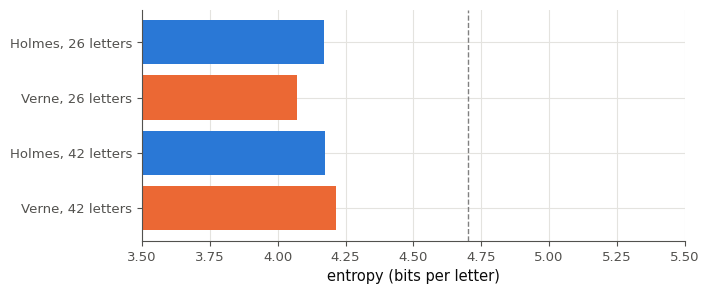

your predictions: a) True   b) False   c) 4


In [13]:
prediction_6_14a, prediction_6_14b, prediction_6_14c = True, False, 4
if True:
    entropies_14 = {}
    for name_14, text_14, alphabet_14 in [("Holmes, 26 letters", holmes, LETTERS), ("Verne, 26 letters", verne, LETTERS),
                                          ("Holmes, 42 letters", holmes, LETTERS_FR),
                                          ("Verne, 42 letters", verne, LETTERS_FR)]:
        _, probs_14 = mylearn.info.char_distribution(text_14, alphabet=alphabet_14)
        entropies_14[name_14] = mylearn.info.entropy(probs_14)
        print(f"{name_14:20s} {entropies_14[name_14]:.4f} bits per letter")
    print(f"the largest possible: {np.log2(26):.4f} bits on 26 letters, {np.log2(42):.4f} on 42")
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(list(entropies_14), list(entropies_14.values()), color=["C0", "C1", "C0", "C1"])
    ax.axvline(np.log2(26), ls="--", color="gray", lw=1)
    ax.set(xlabel="entropy (bits per letter)", xlim=(3.5, 5.5))
    ax.invert_yaxis()
    plt.show()
    print(f"your predictions: a) {prediction_6_14a}   b) {prediction_6_14b}   c) {prediction_6_14c}")

In [14]:
wb.record("6.14a", True)
wb.record("6.14b", False)
wb.record("6.14c", 4.0, decimals=1, choices=[3, 4, 4.7, 5], mistakes={"c'est l'entropie maximale sur 26 lettres, log2 26 ≈ 4,70 : les lettres ne sont pas équiprobables, l'entropie est plus basse": 4.7,
                                               "c'est le nombre de bits d'un code fixe pour 26 lettres : l'entropie est plus basse que ce prix": 5,
                                               "trop bas : avec 26 lettres assez souvent utilisées, la surprise moyenne dépasse 3 bits": 3})
wb.record("6.14d", entropies_14["Holmes, 26 letters"], decimals=4, mistakes={"c'est sur les 42 lettres de LETTERS_FR : on demande les 26 lettres de LETTERS": entropies_14["Holmes, 42 letters"],
                                                                            "c'est en nats : on demande des bits (base 2)": entropies_14["Holmes, 26 letters"] * np.log(2)})
wb.record("6.14e", entropies_14["Verne, 26 letters"], decimals=4, mistakes={"c'est sur les 42 lettres de LETTERS_FR : on demande les 26 lettres de LETTERS": entropies_14["Verne, 42 letters"]})
wb.record("6.14f", entropies_14["Verne, 42 letters"], decimals=4, mistakes={"c'est sur les 26 lettres de LETTERS : on demande les 42 lettres de LETTERS_FR": entropies_14["Verne, 26 letters"]})

WB_ANSWER {"hash": "5db7dca784bfb01dfaf8d15e481a5f5a31a2ddedd93bbd50ccb2896888694573", "id": "6.14a", "kind": "bool"}
📝 Ex 6.14a : réponse enregistrée (bool).
WB_ANSWER {"hash": "f923a44fb0fb1eacfffe4261172ce2f1402c0676eae5640017c66a1c9a6b56c5", "id": "6.14b", "kind": "bool"}
📝 Ex 6.14b : réponse enregistrée (bool).
WB_ANSWER {"choices": ["3.0", "4.0", "4.7", "5.0"], "decimals": 1, "hash": "a841be2eb72e92dca3750faf740cb153251f940c2dbf2bdd86be7628bd832906", "hash_coarse": "224261725fadd9a2e2ec11d96afc195a7328d87bdc7b74a03307478a0406e61d", "id": "6.14c", "kind": "float", "magnitude": 0, "mistakes": {"2ac41fb66f09ef3f5e560b84d72186f79de954364f08eec5e7d0baa4fe5367d6": "c'est le nombre de bits d'un code fixe pour 26 lettres : l'entropie est plus basse que ce prix", "4109c128d775966aabf105fa010e64e05a753fc36e65c1ee48524ca1d5835ba6": "trop bas : avec 26 lettres assez souvent utilisées, la surprise moyenne dépasse 3 bits", "562330e95ca5b0d59a07748e9b245277c34c1f01639a7920ff8ecd1ca764302a": "c'

**Expérience** : exécute la cellule et compare avec tes prédictions.

💡 Sur 26 lettres, Verne a l'entropie la plus basse : le français concentre davantage ses lettres (« e », « s », « a », « u » sont plus fréquents qu'en anglais, « w », « k », « y » presque absents). Sur 42 lettres, c'est l'inverse : les lettres accentuées sont de nouvelles issues, et « é », « è », « ê » partagent la masse de « e » ; la distribution s'étale, l'entropie monte. L'entropie n'est donc pas une propriété d'une langue seule : elle dépend de ce qu'on appelle une « lettre », c'est-à-dire de la distribution qu'on mesure. Le maximum sur 26 lettres vaut $\log_2 26 \approx 4{,}70$ bits.

### Ex 6.15 — Fréquences des lettres en anglais et en français 🎨 ★★ ⏱️ 20 min
**Objectif :** tracer côte à côte les distributions des lettres de deux textes, triées, pour les comparer d'un coup d'œil.  
**Prérequis :** Ex 6.13 · fiche §6.6 · livre §6.6 (figures 6.6 et 6.7) · **Fil rouge :** Holmes/Verne · **Parcours :** C

Le livre trace les fréquences des lettres de *Treasure Island* (figures 6.6 et 6.7). Fais-le pour Holmes **et** Verne, côte à côte. Les deux distributions sont fournies, sur les 26 lettres (`p_holmes_15`, `p_verne_15`).

Écris `draw_letters_15(ax, alphabet, p_holmes, p_verne)` qui trace, sur l'axe `ax`, des **barres horizontales groupées** :
- une ligne par lettre, deux barres par ligne (Holmes et Verne, deux couleurs) ;
- les lettres **triées par fréquence décroissante dans Holmes**, la plus fréquente en haut : `order = np.argsort(-p_holmes)`, puis `ax.invert_yaxis()` ;
- les barres de la ligne $i$ décalées de $\pm 0{,}2$ : `ax.barh(y - 0.2, …, height=0.4, label="Holmes")`, puis la même chose pour Verne à `y + 0.2` ;
- les lettres en étiquettes de l'axe des $y$ (`ax.set_yticks(y)`, `ax.set_yticklabels(...)`), la probabilité en $x$, un titre et une légende.

Dans tes notes : quelles lettres changent le plus de rang d'une langue à l'autre ? Le Morse, conçu pour l'anglais, est-il adapté au français ?

In [15]:
counts_holmes_15 = collections.Counter(letters_only(holmes))      # plain counts: no mylearn needed here
counts_verne_15 = collections.Counter(letters_only(verne))
p_holmes_15 = np.array([counts_holmes_15[c] for c in LETTERS], dtype=float)
p_holmes_15 /= p_holmes_15.sum()
p_verne_15 = np.array([counts_verne_15[c] for c in LETTERS], dtype=float)
p_verne_15 /= p_verne_15.sum()

✅ Ex 6.15 : 52 barres, deux par lettre, aux bonnes longueurs.
✅ Ex 6.15 : les lettres sont triées par fréquence dans Holmes, la plus fréquente en haut.
✅ Ex 6.15 : la légende est là.


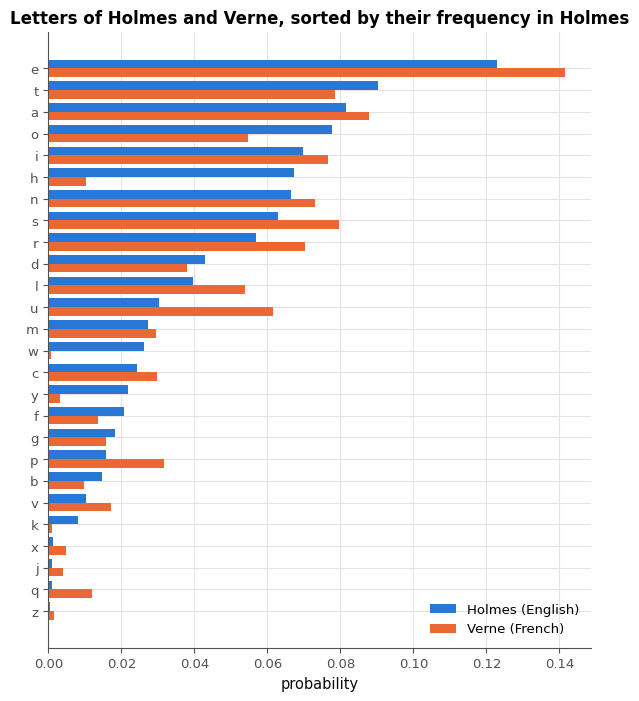

In [16]:
def draw_letters_15(ax, alphabet, p_holmes, p_verne):
    """Grouped horizontal bars of two letter distributions, sorted by p_holmes, the most frequent on top."""
    order = np.argsort(-np.asarray(p_holmes), kind="stable")
    y = np.arange(len(order))
    ax.barh(y - 0.2, np.asarray(p_holmes)[order], height=0.4, label="Holmes (English)")
    ax.barh(y + 0.2, np.asarray(p_verne)[order], height=0.4, label="Verne (French)")
    ax.set_yticks(y)
    ax.set_yticklabels([alphabet[i] for i in order])
    ax.invert_yaxis()
    ax.set(xlabel="probability", title="Letters of Holmes and Verne, sorted by their frequency in Holmes")
    ax.legend(loc="lower right")


if True:
    fig, ax = plt.subplots(figsize=(7, 8))
    try:
        draw_letters_15(ax, LETTERS, p_holmes_15, p_verne_15)
    except BaseException:
        plt.close(fig)                 # no empty figure while draw_letters_15 is not written
        raise
    widths_15 = sorted(round(bar.get_width(), 9) for bar in ax.patches)
    expected_15 = sorted(round(p, 9) for p in np.concatenate([p_holmes_15, p_verne_15]))
    verdict("6.15", widths_15 == expected_15, "52 barres, deux par lettre, aux bonnes longueurs.",
            f"il faut 52 barres horizontales (2 × 26) dont les longueurs sont les probabilités ; j'en compte "
            f"{len(ax.patches)}.")
    positions_15 = ax.get_yticks()
    labels_15 = [label.get_text() for label in ax.get_yticklabels()]
    from_top_15 = [label for _, label in sorted(zip(positions_15, labels_15), reverse=not ax.yaxis_inverted())]
    expected_order_15 = [LETTERS[i] for i in np.argsort(-p_holmes_15, kind="stable")]
    verdict("6.15", from_top_15 == expected_order_15,
            "les lettres sont triées par fréquence dans Holmes, la plus fréquente en haut.",
            f"de haut en bas, j'attends les lettres triées par fréquence dans Holmes ({' '.join(expected_order_15[:5])}…), "
            f"je lis {' '.join(from_top_15[:5])}…")
    verdict("6.15", ax.get_legend() is not None, "la légende est là.", "ajoute une légende (ax.legend()).")
    plt.show()

💡 Le haut du classement se ressemble (e, t, a, o, i, h, n, s dans Holmes ; e, a, s, t, i, n, r, u dans Verne), mais « h », « w », « y » et « k » chutent en français, alors que « u », « q », « v » et « j » montent. Le Morse, réglé sur l'anglais, convient pourtant au français : ses lettres favorites (e, a, i, n, s, t) ont des codes de 1 à 3 symboles, et un texte de Verne demande en moyenne 2,48 points et traits par lettre, contre 2,55 pour Holmes (🔬 6.24). Le coût d'un code fait pour l'autre langue se mesure avec la cross-entropy (6.18, 6.25).

## Partie B · Coder avec le mauvais code : cross-entropy, KL et compression

Fiche §6.8 et §6.9, puis « au-delà du livre » (2). Tu écris la cross-entropy et les divergences, tu répares une cross-entropy infinie, tu mesures ce que coûte d'envoyer le français avec le code de l'anglais, et tu compares l'entropie à un vrai compresseur.

### Ex 6.16 — cross_entropy, kl_divergence et js_divergence 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire la cross-entropy, la divergence KL et celle de Jensen-Shannon, avec leurs cas infinis.  
**Prérequis :** Ex 6.12 · Ex 6.5 · fiche §6.8, §6.9 · **Fil rouge :** synthétique · **mylearn :** `info.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/info.py`, mêmes règles qu'en 6.12 (NumPy et la bibliothèque standard permis, SciPy, scikit-learn et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `cross_entropy(p, q, base=2.0)`, `kl_divergence(p, q, base=2.0)` et `js_divergence(p, q, base=2.0)` (lis leurs docstrings) :
- valide les deux distributions avec ton `_as_distribution` (6.12), et vérifie qu'elles ont la même forme ;
- ne somme que sur les issues où $p_i > 0$ ; si $q_i = 0$ pour l'une d'elles, renvoie `float("inf")`. Teste ce cas **avant** de prendre le logarithme : ni `NaN`, ni avertissement de NumPy ;
- `kl_divergence` renvoie $\sum p_i \log \frac{p_i}{q_i}$ ; les arrondis peuvent donner $-10^{-17}$ quand $q$ est presque $p$ : renvoie alors 0 ;
- `js_divergence` construit le mélange $m = \frac{p + q}{2}$, puis réutilise deux fois `kl_divergence`.

La vérification affiche les valeurs de ✏️ 6.5 calculées par tes fonctions, contrôle deux propriétés, puis lance les tests.

Dans tes notes : pourquoi la divergence de Jensen-Shannon reste-t-elle finie quand la KL est infinie ?

In [17]:
p_16, q_16 = [0.8, 0.2], [0.5, 0.5]
print(f"H(p, q) = {mylearn.info.cross_entropy(p_16, q_16):.4f}   KL(p || q) = {mylearn.info.kl_divergence(p_16, q_16):.4f}   "
      f"KL(q || p) = {mylearn.info.kl_divergence(q_16, p_16):.4f}   JS(p, q) = {mylearn.info.js_divergence(p_16, q_16):.4f}")
print("with an impossible outcome:", mylearn.info.cross_entropy([0.5, 0.5], [1.0, 0.0]),
      mylearn.info.kl_divergence([0.5, 0.5], [1.0, 0.0]), round(mylearn.info.js_divergence([0.5, 0.5], [1.0, 0.0]), 4))
run_info_tests("test_cross_entropy_ or test_kl_divergence_ or test_js_divergence_", impl="ref")

H(p, q) = 1.0000   KL(p || q) = 0.2781   KL(q || p) = 0.3219   JS(p, q) = 0.0731
with an impossible outcome: inf inf 0.3113


pytest: 36 passed, 126 deselected in 2.04s


💡 Le mélange $m = \frac{p + q}{2}$ n'est jamais nul là où $p$ ou $q$ ne l'est pas : les deux KL de la divergence de Jensen-Shannon sont donc toujours finies, et elle ne dépasse jamais 1 bit (atteint quand $p$ et $q$ n'ont aucune issue en commun). C'est la divergence qu'optimise, en un sens, le GAN d'origine (ch. 27).

### Ex 6.17 — La cross-entropy infinie : la lettre qui manque 🐛 ★★ ⏱️ 20 min
**Objectif :** diagnostiquer une cross-entropy infinie, et la corriger par un lissage placé au bon endroit.  
**Prérequis :** Ex 6.16 · fiche §6.8 (lissage de Laplace) · livre §6.8.2 · **Fil rouge :** Holmes/Verne · **Parcours :** C

Une collègue veut savoir combien de bits par lettre coûte l'envoi de Verne avec un code construit sur les lettres de Holmes. Pour garder les accents du français, elle prend l'alphabet `LETTERS_FR` (42 lettres). Son code, ci-dessous, affiche… `inf`. Trouve pourquoi, puis corrige.
a) `n_missing_17` : combien de lettres de `LETTERS_FR` apparaissent dans Verne mais jamais dans Holmes ?
b) `worst_count_17` : le nombre d'apparitions, dans Verne, de la plus fréquente de ces lettres ;
c) `share_17` : la proportion des lettres de Verne (parmi les 42 de `LETTERS_FR`) qui sont des lettres de a) (4 décimales) ;
d) `ce_fixed_17` : corrige le calcul avec le lissage de Laplace (`smoothing=1`), **à un seul endroit**, et donne le nombre de bits par lettre obtenu (4 décimales).

Le cœur de l'exercice est le choix de l'endroit : lisser la distribution de Verne, celle de Holmes, ou les deux ? Que se passe-t-il dans chaque cas ?

In [18]:
# The code of a colleague: the bits per letter to send Verne with a code built on the letters of Holmes
with wb.attempt("6.17"):
    _, p_verne_17 = mylearn.info.char_distribution(verne, alphabet=LETTERS_FR)
    _, q_holmes_17 = mylearn.info.char_distribution(holmes, alphabet=LETTERS_FR)
    print("bits per letter to send Verne with the code of Holmes:", mylearn.info.cross_entropy(p_verne_17, q_holmes_17))

bits per letter to send Verne with the code of Holmes: inf


In [19]:
missing_17 = [c for i, c in enumerate(LETTERS_FR) if p_verne_17[i] > 0 and q_holmes_17[i] == 0]
counts_verne_17 = collections.Counter(verne.lower())
n_missing_17 = len(missing_17)
worst_count_17 = max(counts_verne_17[c] for c in missing_17)
share_17 = sum(p_verne_17[LETTERS_FR.index(c)] for c in missing_17)
_, q_smoothed_17 = mylearn.info.char_distribution(holmes, alphabet=LETTERS_FR, smoothing=1)   # smooth the CODE only
ce_fixed_17 = mylearn.info.cross_entropy(p_verne_17, q_smoothed_17)
print("missing in Holmes:", missing_17, "· counts in Verne:", [counts_verne_17[c] for c in missing_17])
print(f"a) {n_missing_17}   b) {worst_count_17}   c) {share_17:.4f}   d) {ce_fixed_17:.4f} bits per letter")
_, p_smoothed_17 = mylearn.info.char_distribution(verne, alphabet=LETTERS_FR, smoothing=1)
print("smoothing Verne instead:", mylearn.info.cross_entropy(p_smoothed_17, q_holmes_17),
      "· smoothing both:", round(mylearn.info.cross_entropy(p_smoothed_17, q_smoothed_17), 4),
      "· KL after the fix:", round(mylearn.info.kl_divergence(p_verne_17, q_smoothed_17), 4))

missing in Holmes: ['ç', 'ê', 'ë', 'î', 'ï', 'ô', 'ù', 'û', 'ü'] · counts in Verne: [265, 692, 1, 268, 26, 181, 114, 251, 1]
a) 9   b) 692   c) 0.0054   d) 4.6708 bits per letter
smoothing Verne instead: inf · smoothing both: 4.6716 · KL after the fix: 0.4543


In [20]:
absent_17 = [c for i, c in enumerate(LETTERS_FR) if q_holmes_17[i] == 0]
wb.record("6.17a", n_missing_17, mistakes={"une lettre absente des DEUX livres (comme « ÿ ») ne gêne pas : 0 log 0 = 0 ; ne compte que celles que Verne utilise": len(absent_17)})
wb.record("6.17b", worst_count_17, mistakes={"« é » apparaît aussi dans Holmes (une douzaine de fois) : ce n'est pas une lettre qui manque": counts_verne_17["é"]})
wb.record("6.17c", share_17, decimals=4, mistakes={"c'est en pourcentage : on demande une proportion entre 0 et 1": 100 * share_17})
wb.record("6.17d", ce_fixed_17, decimals=4, mistakes={"tu as lissé aussi Verne : lisse seulement la distribution du code (Holmes), les données restent ce qu'elles sont": mylearn.info.cross_entropy(p_smoothed_17, q_smoothed_17),
                                                       "le lissage demandé ajoute 1 à chaque compte (smoothing=1)": mylearn.info.cross_entropy(p_verne_17, mylearn.info.char_distribution(holmes, alphabet=LETTERS_FR, smoothing=0.5)[1]),
                                                       "c'est en nats : on demande des bits par lettre (base 2)": mylearn.info.cross_entropy(p_verne_17, q_smoothed_17, base=np.e),
                                                       "toujours infini : une probabilité nulle reste dans la distribution du code ; vérifie laquelle tu as lissée": float("inf")})

WB_ANSWER {"hash": "6ebe52ce7385304898ac4cb3209f97c9bb12eb9d9893f330c1ef086b97eafd6c", "id": "6.17a", "kind": "int", "magnitude": 0, "mistakes": {"1f9b2b386b8fc2fae9dde8695e1ca5a9f570fc2a5035b0a3274fcfbcfe67b5f3": "une lettre absente des DEUX livres (comme « ÿ ») ne gêne pas : 0 log 0 = 0 ; ne compte que celles que Verne utilise"}, "sign": 1}
📝 Ex 6.17a : réponse enregistrée (int).
WB_ANSWER {"hash": "7fb3031a58a40a3293b1681ec8aa324775b6af916bdc8ec5c7c44c0ec90a98b8", "id": "6.17b", "kind": "int", "magnitude": 2, "mistakes": {"2f357ee874a3e79b8e13cfd1f12dc3d4c458ec44ea072b0edca876cd4413ba45": "« é » apparaît aussi dans Holmes (une douzaine de fois) : ce n'est pas une lettre qui manque"}, "sign": 1}
📝 Ex 6.17b : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "90e9926c4e1511d41b8484c1edd3fa96ce843ca10cb5e48dc61f4f7321e21959", "hash_coarse": "9c14c61e8905f15e881cb96ede10d5173d642460e2c4c4986c32612e3e41a57a", "id": "6.17c", "kind": "float", "magnitude": -3, "mistakes": {"dd94e

WB_ANSWER {"decimals": 4, "hash": "b88d1205e5b42a0146b7ed33260181567655413e9e76d02e79907d5a2966cb47", "hash_coarse": "d505f1cc5b1953360c47916b86dfa4acb951935d1b07008a0d7a9dddd32f75d9", "id": "6.17d", "kind": "float", "magnitude": 0, "mistakes": {"65f2ecfcf62d2c31e36ccbedfd100fdcdb9a42b640ca97abd1d633f0286752e8": "tu as lissé aussi Verne : lisse seulement la distribution du code (Holmes), les données restent ce qu'elles sont", "b43fab69577d6a925cb25e0a1a67bfcd9cc93235d76dcaa3ff7af15dd71288e0": "le lissage demandé ajoute 1 à chaque compte (smoothing=1)", "cae0038ca7cee65db3fcf57ab5d03358ab8a5087206efa4ea3ade00a4ceaf26e": "c'est en nats : on demande des bits par lettre (base 2)", "eeaec5c5483256cecc181c8e438811bdaabae74d3483722a180758f6f3e64485": "toujours infini : une probabilité nulle reste dans la distribution du code ; vérifie laquelle tu as lissée"}, "sign": 1}
📝 Ex 6.17d : réponse enregistrée (float, 4 décimale(s)).


💡 Neuf lettres de Verne (ç, ê, ë, î, ï, ô, ù, û, ü) n'apparaissent jamais dans Holmes : le code de Holmes leur donne une probabilité nulle, donc une surprise infinie, et une seule suffit à rendre la moyenne infinie. Le lissage doit porter sur le **code** (Holmes) : lisser Verne ne change rien au problème (une probabilité nulle dans le code reste nulle), et lisser les deux modifie les données qu'on mesure. Ces lettres ne font que 0,5 % des lettres de Verne ; avec le code lissé, chacune coûte environ 18,7 bits. La KL après correction (0,45 bit) est plus du double de celle des 26 lettres (6.18) : les neuf lettres manquantes n'y comptent que pour 0,05 bit ; « é », qui n'apparaît que 12 fois dans Holmes mais fait 1,8 % des lettres de Verne, coûte 15 bits à chaque apparition et pèse à lui seul 0,17 bit.

### Ex 6.18 — Coder le français avec le code de l'anglais, et l'inverse 🔬 ★★ ⏱️ 25 min
**Objectif :** mesurer le surcoût d'un code fait pour une autre langue, dans les deux sens, et voir l'asymétrie de la KL.  
**Prérequis :** Ex 6.13 · Ex 6.16 · fiche §6.8, §6.9 · livre §6.8.2, §6.9 · **Fil rouge :** Holmes/Verne · **Parcours :** R, C

Le livre envoie *Treasure Island* avec le code de *Huckleberry Finn*. Fais de même avec deux langues. Sur les 26 lettres (`LETTERS`, accents ignorés, toutes présentes dans les deux livres), avec tes fonctions (4 décimales) :
a) `ce_verne_holmes_18` : le nombre de bits par lettre pour envoyer Verne avec le code idéal de Holmes, $H(p_{\text{Verne}}, q_{\text{Holmes}})$ ;
b) `ce_holmes_verne_18` : l'inverse, Holmes avec le code de Verne ;
c) `kl_verne_holmes_18` : $\mathrm{KL}(\text{Verne} \,\|\, \text{Holmes})$, le surcoût de a) par rapport au code idéal de Verne ;
d) `kl_holmes_verne_18` : $\mathrm{KL}(\text{Holmes} \,\|\, \text{Verne})$ ;
e) `js_18` : la divergence de Jensen-Shannon entre les deux distributions ;
f) `kl_halves_18` : la KL entre la première et la seconde moitié du **texte** de Holmes, `holmes[:len(holmes) // 2]` et `holmes[len(holmes) // 2:]`, dans cet ordre (5 décimales).

Une fois c) et d) remplis, la cellule suivante trace la contribution de chaque lettre à ces deux KL.

Dans tes notes : quel envoi coûte le plus cher, et pourquoi ? Quelles lettres pèsent le plus dans d) ? Que dit f) ?

In [21]:
_, p_h_18 = mylearn.info.char_distribution(holmes, alphabet=LETTERS)
_, p_v_18 = mylearn.info.char_distribution(verne, alphabet=LETTERS)
ce_verne_holmes_18 = mylearn.info.cross_entropy(p_v_18, p_h_18)
ce_holmes_verne_18 = mylearn.info.cross_entropy(p_h_18, p_v_18)
kl_verne_holmes_18 = mylearn.info.kl_divergence(p_v_18, p_h_18)
kl_holmes_verne_18 = mylearn.info.kl_divergence(p_h_18, p_v_18)
js_18 = mylearn.info.js_divergence(p_h_18, p_v_18)
middle_18 = len(holmes) // 2
_, first_18 = mylearn.info.char_distribution(holmes[:middle_18], alphabet=LETTERS)
_, second_18 = mylearn.info.char_distribution(holmes[middle_18:], alphabet=LETTERS)
kl_halves_18 = mylearn.info.kl_divergence(first_18, second_18)
print(f"a) {ce_verne_holmes_18:.4f}   b) {ce_holmes_verne_18:.4f}   c) {kl_verne_holmes_18:.4f}   "
      f"d) {kl_holmes_verne_18:.4f}   e) {js_18:.4f}   f) {kl_halves_18:.5f}")

a) 4.2734   b) 4.4816   c) 0.2014   d) 0.3092   e) 0.0538   f) 0.00041


In [22]:
wb.record("6.18a", ce_verne_holmes_18, decimals=4, mistakes={"c'est Holmes envoyé avec le code de Verne (b) : les données sont Verne, le code est Holmes": ce_holmes_verne_18,
                                                                    "c'est en nats : on demande des bits": mylearn.info.cross_entropy(p_v_18, p_h_18, base=np.e)})
wb.record("6.18b", ce_holmes_verne_18, decimals=4, mistakes={"c'est Verne envoyé avec le code de Holmes (a) : les données sont Holmes, le code est Verne": ce_verne_holmes_18})
wb.record("6.18c", kl_verne_holmes_18, decimals=4, mistakes={"c'est KL(Holmes ‖ Verne) (d) : le premier argument est la distribution des données envoyées, Verne": kl_holmes_verne_18,
                                                              "c'est en nats : on demande des bits": mylearn.info.kl_divergence(p_v_18, p_h_18, base=np.e)})
wb.record("6.18d", kl_holmes_verne_18, decimals=4, mistakes={"c'est KL(Verne ‖ Holmes) (c) : ici, les données envoyées sont Holmes": kl_verne_holmes_18})
wb.record("6.18e", js_18, decimals=4, mistakes={"c'est la moyenne des deux KL c) et d) : la divergence de Jensen-Shannon compare chaque distribution au MÉLANGE m = (p + q) / 2": (kl_verne_holmes_18 + kl_holmes_verne_18) / 2,
                                                "c'est la RACINE de la divergence (scipy.spatial.distance.jensenshannon renvoie une distance) : on demande la divergence elle-même": float(np.sqrt(js_18))})
wb.record("6.18f", kl_halves_18, decimals=5, mistakes={"c'est KL(seconde moitié ‖ première moitié) : l'ordre compte": mylearn.info.kl_divergence(second_18, first_18)})

WB_ANSWER {"decimals": 4, "hash": "ee242666e9ded59e31a6e44323b4ebb43d4f21204698a743a3f1ccf458b10c21", "hash_coarse": "3f7142ca1ff781bd119cc55565514fb1375eae9143119563f98b38c824e78cb4", "id": "6.18a", "kind": "float", "magnitude": 0, "mistakes": {"83bf7c5b429c94b02f658831c6f73b359dd5515d8761bcfd3c0874cbc0b4cc06": "c'est en nats : on demande des bits", "e5a14e8b7a5ae708227f8f73946e045aa9538bcc731d67661c1e45fd617e7d3b": "c'est Holmes envoyé avec le code de Verne (b) : les données sont Verne, le code est Holmes"}, "sign": 1}
📝 Ex 6.18a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "5509c613241d40ca45acf806be5b6aa616ea2428508891fb056c2cd3cc0752ba", "hash_coarse": "a5f8445d97a9a1b035cd92cd202b928976a4efeb04d732141f153d0950c3be17", "id": "6.18b", "kind": "float", "magnitude": 0, "mistakes": {"80f91b8c3be76a78454a68424cf30da94dedfd36afbeb3ad5f3832918365483e": "c'est Verne envoyé avec le code de Holmes (a) : les données sont Holmes, le code est Verne"}, "sign":

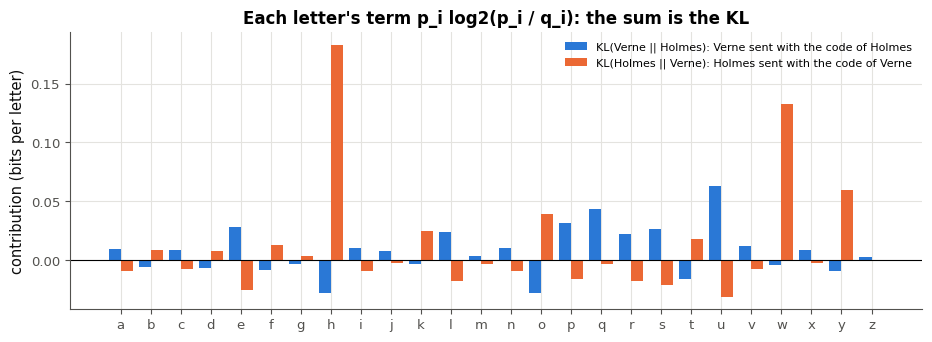

In [23]:
if filled(kl_verne_holmes_18, kl_holmes_verne_18):
    with wb.attempt("6.18"):
        _, p_h_18 = mylearn.info.char_distribution(holmes, alphabet=LETTERS)
        _, p_v_18 = mylearn.info.char_distribution(verne, alphabet=LETTERS)
        fig, ax = plt.subplots(figsize=(11, 3.6))
        x_18 = np.arange(26)
        ax.bar(x_18 - 0.2, p_v_18 * np.log2(p_v_18 / p_h_18), width=0.4, label="KL(Verne || Holmes): Verne sent with the code of Holmes")
        ax.bar(x_18 + 0.2, p_h_18 * np.log2(p_h_18 / p_v_18), width=0.4, label="KL(Holmes || Verne): Holmes sent with the code of Verne")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(x_18)
        ax.set_xticklabels(list(LETTERS))
        ax.set(ylabel="contribution (bits per letter)", title="Each letter's term p_i log2(p_i / q_i): the sum is the KL")
        ax.legend(fontsize=8)
        plt.show()
else:
    print("⏳ Ex 6.18 : remplis d'abord c) et d) ; la figure des contributions s'affichera ici.")

💡 Envoyer Holmes avec le code de Verne coûte plus cher (0,31 bit par lettre de plus) que l'inverse (0,20) : la KL pondère chaque écart par la fréquence dans les **données**. Holmes utilise beaucoup de « h » (6,7 % de ses lettres), de « w » et de « y », que le français rend rares : le code de Verne leur donne des mots longs, et ils reviennent souvent. Dans l'autre sens, les lettres que le français préfère (« u », « q ») ne sont pas si rares en anglais. Entre les deux moitiés de Holmes, la KL est quasi nulle (4 dix-millièmes de bit) : même auteur, même langue, même distribution. Tout cela pour 26 lettres ; le livre trouve des écarts du même ordre entre deux romans anglais, mais sur des **mots** (0,29 et 0,5 bit par mot).

### Ex 6.19 — scipy.stats.entropy et un vrai compresseur (zlib) 📦 ★★ ⏱️ 20 min
**Objectif :** utiliser `scipy.stats.entropy` et un compresseur de la bibliothèque standard, et voir qu'un compresseur exploite le contexte.  
**Prérequis :** Ex 6.13 · fiche §6.7, au-delà du livre (2) (🧮 compression) · livre §6.2.2 · **Fil rouge :** Holmes · **Parcours :** C

1. `scipy.stats.entropy(pk, qk=None, base=None)` calcule l'entropie, et la KL si on lui donne `qk`. Lis sa documentation (`help(scipy.stats.entropy)`) : accepte-t-elle des **comptes** au lieu de probabilités ? Quelle base utilise-t-elle par défaut ?
a) `h_chars_19` : l'entropie, en bits par caractère, de la distribution de **tous** les caractères de Holmes, tels quels (majuscules, espaces, ponctuation, retours à la ligne, sans passer en minuscules), avec `scipy.stats.entropy` appliquée aux comptes de `collections.Counter(holmes)` (4 décimales).

2. Le module `zlib` de la bibliothèque standard comprime sans perte (fiche, 🧮 compression) : `zlib.compress(data, 9)` prend des octets (`holmes.encode("utf-8")`) et renvoie des octets, au niveau de compression 9 (le plus fort).
b) `zlib_bits_19` : le nombre de **bits** du texte comprimé, divisé par le nombre de **caractères** de Holmes (1 décimale) ;
c) `shuffled_bits_19` : la même mesure sur Holmes **mélangé** : exactement les mêmes caractères, dans un ordre aléatoire, `"".join(np.random.default_rng(19).permutation(list(holmes)))` (1 décimale) ;
d) `zlib_wins_19` : sur le vrai texte, zlib fait-il mieux que l'entropie a) ? (`True` ou `False`)

Dans tes notes : comment zlib peut-il descendre sous l'entropie a), qui suppose chaque caractère tiré indépendamment des autres ? Pourquoi fait-il moins bien sur le texte mélangé, qui a pourtant exactement la même distribution de caractères ?

In [24]:
counts_19 = collections.Counter(holmes)
h_chars_19 = scipy.stats.entropy(list(counts_19.values()), base=2)          # counts are fine: SciPy normalizes them
zlib_bits_19 = 8 * len(zlib.compress(holmes.encode("utf-8"), 9)) / len(holmes)
shuffled_19 = "".join(np.random.default_rng(19).permutation(list(holmes)))
shuffled_bits_19 = 8 * len(zlib.compress(shuffled_19.encode("utf-8"), 9)) / len(holmes)
zlib_wins_19 = zlib_bits_19 < h_chars_19
print(f"a) {h_chars_19:.4f} bits per character   b) zlib {zlib_bits_19:.4f}   c) shuffled {shuffled_bits_19:.4f}   "
      f"d) {zlib_wins_19}")
print("scipy.stats.entropy([0.5, 0.5]) without base:", scipy.stats.entropy([0.5, 0.5]), "(nats)")

a) 4.4858 bits per character   b) zlib 3.0987   c) shuffled 5.1119   d) True
scipy.stats.entropy([0.5, 0.5]) without base: 0.6931471805599453 (nats)


In [25]:
wb.record("6.19a", h_chars_19, decimals=4, mistakes={"tu as passé le texte en minuscules : on garde les caractères tels quels": scipy.stats.entropy(list(collections.Counter(holmes.lower()).values()), base=2),
                                                    "c'est en nats, la base par défaut de SciPy : passe base=2": scipy.stats.entropy(list(counts_19.values()))})
wb.record("6.19b", zlib_bits_19, decimals=1, mistakes={"tu as divisé par le nombre d'OCTETS : on demande des bits par CARACTÈRE": 8 * len(zlib.compress(holmes.encode("utf-8"), 9)) / len(holmes.encode("utf-8")),
                                                       "c'est le nombre d'octets par caractère : un octet vaut 8 bits": len(zlib.compress(holmes.encode("utf-8"), 9)) / len(holmes)})
wb.record("6.19c", shuffled_bits_19, decimals=1)
wb.record("6.19d", True)

WB_ANSWER {"decimals": 4, "hash": "c1c909dd859ec5d37e40e0e466c773fa08611088e46512d447d0fdb754a05f48", "hash_coarse": "6d134e1125a9effabcb11c0b62a4c7cfe768b47d92ec15d1dd4262f5d62dbc00", "id": "6.19a", "kind": "float", "magnitude": 0, "mistakes": {"30f28f841f96f909203a8d1ae0d561f69817ec70d88db963e22bcdba0cd972b1": "tu as passé le texte en minuscules : on garde les caractères tels quels", "e79965f1de934d65952d3cfda1d82e076138eb10a495dc4b6423a69f9ba9194e": "c'est en nats, la base par défaut de SciPy : passe base=2"}, "sign": 1}
📝 Ex 6.19a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 1, "hash": "a668c56aea3f0b55b954eb2e3325b88f508dd650875bdbd2b13b3e76502552fe", "hash_coarse": "39d5864dfbb3b7f49db1bdd074a7d23b9f5e3d022fe6cae6c2bcf21c1fdcf569", "id": "6.19b", "kind": "float", "magnitude": 0, "mistakes": {"51b883a1b37c7e6cca4fe32a314b042714f71a449eacd4fef3be6edacc136108": "c'est le nombre d'octets par caractère : un octet vaut 8 bits", "81a6318ad6fb50e48e7820caf6580b197

💡 zlib descend à environ 3,1 bits par caractère, sous l'entropie des caractères pris un par un (4,49) : il repère les suites déjà vues (des mots entiers, « Sherlock Holmes », « said he ») et les remplace par une référence courte. C'est le contexte local du §6.2.2 : l'entropie « lettre à lettre » n'est un plancher que pour un code qui ignore ce contexte. Mélangé, le texte garde exactement la même distribution de caractères, mais plus aucune répétition : zlib n'a plus rien d'utile à exploiter. Il passe même au-dessus de l'entropie : il code encore de courtes répétitions dues au hasard, qui coûtent plus cher que les caractères qu'elles remplacent ; il code des octets UTF-8 (575 794 octets pour 562 203 caractères), et des longueurs de mots de code entières. Les valeurs de zlib peuvent varier très légèrement d'une version de la bibliothèque à l'autre : d'où la seule décimale.

## Partie C · Bits, nats et perplexité : la loss des modèles de langage

Fiche, au-delà du livre (1). Tu lis une courbe de loss en nats, tu mesures la vitesse de plusieurs façons de compter des lettres, puis tu écris la perplexité et la log loss, la loss de presque tous les classifieurs.

### Ex 6.20 — Lire une courbe de loss : nats, bits et perplexité 📈 ★★ ⏱️ 20 min
**Objectif :** lire une courbe de loss en nats, la convertir en bits et en perplexité, et repérer l'overfitting.  
**Prérequis :** Ex 6.16 · fiche, au-delà du livre (1) · **Fil rouge :** synthétique · **Parcours :** R, M

Un modèle de langage au niveau des caractères (il prédit le caractère suivant) a été entraîné pendant 3 000 pas. On a noté sa loss, la cross-entropy en **nats** comme dans PyTorch, sur les données d'entraînement (`train_20`) et sur des données de validation (`val_20`), tous les 25 pas (`steps_20`). Lis la figure, puis réponds avec les tableaux :
a) `vocab_20` : au pas 0, le modèle n'a rien appris et répartit ses probabilités uniformément entre tous les caractères possibles. Combien de caractères y a-t-il ? (un entier)
b) `best_step_20` : le pas où la loss de **validation** est la plus basse ;
c) `best_bits_20` : cette loss minimale, en bits par caractère (3 décimales) ;
d) `best_ppl_20` : la perplexité correspondante (2 décimales) ;
e) `ppl3_step_20` : le premier pas où la perplexité de validation passe sous 3 ;
f) `last_ppl_20` : la perplexité de validation au dernier pas (2 décimales).

Dans tes notes : que se passe-t-il après le pas b) ? Quel nom porte ce phénomène (ch. 9), et que ferais-tu ?

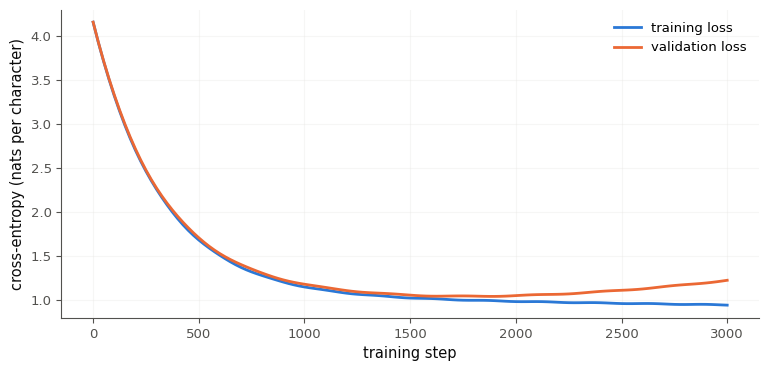

In [26]:
steps_20 = np.arange(0, 3001, 25)                     # the training steps where the loss was measured
decay_20 = 1.05 + (np.log(64) - 1.05) * np.exp(-steps_20 / 320) - 0.000035 * steps_20
train_20 = decay_20 + 0.003 * np.sin(steps_20 / 41)                                # loss on the training data (nats)
val_20 = (decay_20 + 0.03 * (1 - np.exp(-steps_20 / 300))                          # loss on validation data (nats)
          + 0.25 * np.clip((steps_20 - 1400) / 1600, 0, None) ** 2 + 0.004 * np.sin(steps_20 / 53))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps_20, train_20, label="training loss")
ax.plot(steps_20, val_20, label="validation loss")
ax.set(xlabel="training step", ylabel="cross-entropy (nats per character)", ylim=(0.8, 4.3))
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [27]:
vocab_20 = round(float(np.exp(val_20[0])))           # perplexity of a uniform guess = number of choices
best_20 = int(np.argmin(val_20))
best_step_20 = int(steps_20[best_20])
best_bits_20 = val_20[best_20] / np.log(2)
best_ppl_20 = np.exp(val_20[best_20])
ppl3_step_20 = int(steps_20[np.argmax(np.exp(val_20) < 3)])
last_ppl_20 = np.exp(val_20[-1])
print(f"a) {vocab_20}   b) {best_step_20}   c) {best_bits_20:.3f} bits   d) {best_ppl_20:.2f}   e) {ppl3_step_20}   "
      f"f) {last_ppl_20:.2f} (training: {np.exp(train_20[-1]):.2f})")

a) 64   b) 1900   c) 1.504 bits   d) 2.84   e) 1250   f) 3.41 (training: 2.57)


In [28]:
wb.record("6.20a", vocab_20, mistakes={"c'est la loss elle-même : le nombre de choix est la perplexité, exp(loss)": int(round(val_20[0])),
                                       "la loss est en nats : la perplexité vaut exp(loss), pas 2 ** loss": int(round(2 ** val_20[0]))})
wb.record("6.20b", best_step_20, mistakes={"c'est le minimum de la loss d'ENTRAÎNEMENT, qui baisse jusqu'au bout : on demande celui de la validation": int(steps_20[np.argmin(train_20)]),
                                           "c'est la POSITION du minimum dans le tableau (np.argmin) : le pas correspondant est steps_20[position]": int(np.argmin(val_20))})
wb.record("6.20c", best_bits_20, decimals=3, mistakes={"c'est en nats : divise par ln 2 pour avoir des bits": val_20[best_20],
                                                      "pour passer des nats aux bits, on DIVISE par ln 2": val_20[best_20] * np.log(2)})
wb.record("6.20d", best_ppl_20, decimals=2, mistakes={"la loss est en nats : la perplexité vaut exp(loss), pas 2 ** loss": 2 ** val_20[best_20]})
wb.record("6.20e", ppl3_step_20, mistakes={"c'est le pas juste AVANT le passage sous 3 : on demande le premier pas en dessous": int(steps_20[np.argmax(np.exp(val_20) < 3) - 1]),
                                           "tu as comparé la loss elle-même à 3 : compare la perplexité, exp(loss)": int(steps_20[np.argmax(val_20 < 3)]),
                                           "la loss est en nats : la perplexité vaut exp(loss), pas 2 ** loss": int(steps_20[np.argmax(2 ** val_20 < 3)]),
                                           "c'est sur la courbe d'ENTRAÎNEMENT : on demande la perplexité de validation": int(steps_20[np.argmax(np.exp(train_20) < 3)]),
                                           "c'est une POSITION dans le tableau : le pas correspondant est steps_20[position]": int(np.argmax(np.exp(val_20) < 3))})
wb.record("6.20f", last_ppl_20, decimals=2, mistakes={"c'est la perplexité d'ENTRAÎNEMENT au dernier pas : on demande celle de validation": np.exp(train_20[-1]),
                                                     "la loss est en nats : la perplexité vaut exp(loss), pas 2 ** loss": 2 ** val_20[-1]})

WB_ANSWER {"hash": "64dae02341d0237977f639ef98672bba38e9e5385534d3175682c7e3c75db950", "id": "6.20a", "kind": "int", "magnitude": 1, "mistakes": {"4a64ac315162cb910d8fec15def37a9aadc8b55a7edf935f8f5755282643036b": "c'est la loss elle-même : le nombre de choix est la perplexité, exp(loss)", "eaafb7576970d8fb14ba4a962b322c29e9cb6c4e5c4d1b435e59f4905a35db7e": "la loss est en nats : la perplexité vaut exp(loss), pas 2 ** loss"}, "sign": 1}
📝 Ex 6.20a : réponse enregistrée (int).
WB_ANSWER {"hash": "4974c1749f13f54a71630bd9b8b14aedbf74cda258d420f3f89a4d2d515c7e9a", "id": "6.20b", "kind": "int", "magnitude": 3, "mistakes": {"ad065766f9df7247b01cf89413678246c7700a9d5cc1bc506d1da8f71663e0f4": "c'est la POSITION du minimum dans le tableau (np.argmin) : le pas correspondant est steps_20[position]", "c688cc27a16f430542ef923fca021c992ca1b3b21dfa2bcffa2eeff7370ee58a": "c'est le minimum de la loss d'ENTRAÎNEMENT, qui baisse jusqu'au bout : on demande celui de la validation"}, "sign": 1}
📝 Ex 6.20b :

💡 Au pas 0, la loss vaut $\ln 64 \approx 4{,}159$ nats : un modèle qui hésite uniformément entre 64 caractères a une perplexité de 64. Au meilleur pas (1 900), la loss de validation vaut environ 1,04 nat, soit 1,50 bit par caractère et une perplexité de 2,84 : le modèle hésite, en moyenne, comme entre moins de trois caractères. Ensuite, la loss d'entraînement continue de baisser alors que celle de validation remonte : c'est l'**overfitting** (*surapprentissage*, ch. 9). On garderait le modèle du meilleur pas (*early stopping*), ou l'on régulariserait.

### Ex 6.21 — Mesurer avant d'optimiser : compter des caractères vite 🛠️ ★★ ⏱️ 20 min
**Objectif :** mesurer la durée de plusieurs implémentations avec `timeit`, avant de choisir laquelle garder.  
**Prérequis :** Ex 6.13 · 0A (`Counter`, NumPy) · fiche §6.5 · **Fil rouge :** Holmes · **Parcours :** C

Avant d'optimiser un calcul, un professionnel **mesure**. Écris quatre fonctions qui renvoient le tableau des comptes des 26 lettres (dans l'ordre de `LETTERS`, des entiers) d'un texte déjà en minuscules :
1. `count_loop_21(text)` : une boucle `for` sur les caractères et un dictionnaire ;
2. `count_counter_21(text)` : `collections.Counter(text)`, puis les 26 comptes ;
3. `count_str_21(text)` : la méthode `text.count(letter)`, une fois par lettre (26 passages sur le texte, mais écrits en C) ;
4. `count_numpy_21(text)` : les octets du texte, `np.frombuffer(text.encode("ascii", "ignore"), dtype=np.uint8)`, puis `np.bincount(…, minlength=123)` et la tranche des codes 97 à 122 (`ord("a")` à `ord("z")`).

Avant de lancer la mesure, note dans `06_mes_reponses.md` laquelle tu crois la plus rapide. La cellule de vérification compare chaque résultat aux comptes de `Counter`, puis mesure chaque fonction avec `timeit.repeat(lambda: f(text), number=3, repeat=5)` : elle garde le **minimum** des cinq mesures, divisé par 3.

Dans tes notes : laquelle est la plus rapide, et de combien ? Était-ce ta prédiction ? Pourquoi garder le minimum de plusieurs mesures plutôt qu'une seule ? Que mesure `time.perf_counter()`, et pourquoi `timeit` l'utilise-t-il ?

In [29]:
holmes_lower_21 = holmes.lower()        # counted once lowered: we only time the counting

In [30]:
def count_loop_21(text):
    """The 26 counts of the letters a-z in text (already lower-cased), with a for loop and a dict."""
    counts = {letter: 0 for letter in LETTERS}
    for ch in text:
        if ch in counts:
            counts[ch] += 1
    return np.array([counts[letter] for letter in LETTERS])


def count_counter_21(text):
    """The same 26 counts, with collections.Counter."""
    counts = collections.Counter(text)
    return np.array([counts[letter] for letter in LETTERS])


def count_str_21(text):
    """The same 26 counts, with text.count(letter)."""
    return np.array([text.count(letter) for letter in LETTERS])


def count_numpy_21(text):
    """The same 26 counts, with np.frombuffer and np.bincount."""
    codes = np.frombuffer(text.encode("ascii", "ignore"), dtype=np.uint8)
    return np.bincount(codes, minlength=123)[ord("a"):ord("z") + 1]


def check_counts_21(name, function):
    """The 26 counts of `function` on holmes_lower_21, compared with collections.Counter; then the best time."""
    counts = np.asarray(function(holmes_lower_21))
    ok = counts.shape == (26,) and np.array_equal(counts, reference_21)
    verdict("6.21", ok, f"{name} : les 26 comptes sont justes.",
            f"{name} doit renvoyer les 26 comptes, dans l'ordre de LETTERS (forme {counts.shape}).")
    seconds = min(timeit.repeat(lambda: function(holmes_lower_21), number=3, repeat=5)) / 3
    return seconds if ok else None


counter_21 = collections.Counter(holmes_lower_21)
reference_21 = np.array([counter_21[c] for c in LETTERS])
times_21 = {}
for name_21, function_21 in [("count_loop_21", count_loop_21), ("count_counter_21", count_counter_21),
                             ("count_str_21", count_str_21), ("count_numpy_21", count_numpy_21)]:
    with wb.attempt(f"6.21 ({name_21})"):
        times_21[name_21] = check_counts_21(name_21, function_21)
done_21 = {name: seconds for name, seconds in times_21.items() if seconds is not None}
if done_21:
    fastest_21 = min(done_21.values())
    for name_21, seconds_21 in sorted(done_21.items(), key=lambda item: item[1]):
        print(f"{name_21:18s} {1000 * seconds_21:8.2f} ms   ({seconds_21 / fastest_21:5.1f} × the fastest)")

✅ Ex 6.21 : count_loop_21 : les 26 comptes sont justes.


✅ Ex 6.21 : count_counter_21 : les 26 comptes sont justes.


✅ Ex 6.21 : count_str_21 : les 26 comptes sont justes.
✅ Ex 6.21 : count_numpy_21 : les 26 comptes sont justes.
count_numpy_21         1.44 ms   (  1.0 × the fastest)
count_str_21           9.73 ms   (  6.7 × the fastest)
count_counter_21      17.36 ms   ( 12.0 × the fastest)
count_loop_21         33.01 ms   ( 22.9 × the fastest)


💡 Sur la machine où ce corrigé a tourné, la version NumPy est de loin la plus rapide (environ 2 ms) ; `str.count` vient ensuite (environ 8 fois plus lente, malgré ses 26 passages, parce que chacun est écrit en C), puis `Counter` (environ 15 fois) et la boucle Python (environ 30 fois) : c'est l'interpréteur, pas le nombre de passages, qui coûte. Les rapports exacts dépendent de la machine : c'est pourquoi on mesure. Une seule mesure est bruitée (autres programmes, caches) ; le minimum de plusieurs répétitions approche le coût du code lui-même. `time.perf_counter()` lit l'horloge la plus précise disponible, faite pour mesurer des durées courtes.

### Ex 6.22 — perplexity et log_loss 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire la perplexité d'un modèle et la log loss d'un classifieur, et les appliquer à un modèle de lettres.  
**Prérequis :** Ex 6.16 · ch. 3 (probabilités prédites, calibration) · fiche, au-delà du livre (1) · **Fil rouge :** Holmes · **mylearn :** `info.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/info.py`, mêmes règles qu'en 6.12 (NumPy et la bibliothèque standard permis, SciPy, scikit-learn et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `perplexity(token_probs)` et `log_loss(y_true, y_prob, base=np.e)` (lis leurs docstrings) :
- `perplexity` : l'exponentielle de la moyenne des $-\ln p_i$, où $p_i$ est la probabilité que le modèle donnait au token réellement observé ; elle ne dépend pas de la base (fiche, au-delà du livre (1)) ;
- `log_loss` : pour chaque exemple, la probabilité que le modèle a donnée à la **vraie** classe (en binaire, `y_prob` est la probabilité de la classe 1, donc celle de la classe 0 vaut `1 - y_prob`), coupée (`np.clip`, sur une copie) dans $[\varepsilon ; 1 - \varepsilon]$ avec $\varepsilon$ = `np.finfo(float).eps`, puis la moyenne des $-\log$ dans la base demandée (des **nats** par défaut, comme scikit-learn) ;
- valide les entrées comme le disent les docstrings : longueurs, étiquettes entières dans le bon intervalle, probabilités dans $[0 ; 1]$ (ce qui exclut `NaN`), lignes de somme 1.

La vérification appelle tes fonctions avec le modèle de lettres de Holmes `model_22` (fourni : les probabilités des 26 lettres sur tout le livre, lissées) :
a) la perplexité de ce modèle sur les lettres de la phrase anglaise `english_22` ;
b) sur sa traduction française, `french_22` ;
c) sur le pangramme anglais `pangram_22` (une phrase qui contient les 26 lettres) ;
puis, avec `log_loss` :
d) la log loss, en nats, des prédictions binaires `p_22` pour les vraies classes `y_22` ;
e) la log loss, en **bits**, des prédictions à trois classes `P3_22` pour `y3_22` ;
et lance enfin les tests des deux fonctions.

Dans tes notes : pourquoi la phrase française surprend-elle davantage le modèle de Holmes ? Pourquoi le pangramme le surprend-il encore plus, alors qu'il est en anglais ?

In [31]:
counts_22 = collections.Counter(letters_only(holmes))
model_22 = np.array([counts_22[c] + 1 for c in LETTERS], dtype=float)       # Laplace smoothing (6.13)
model_22 /= model_22.sum()                                                   # the probability of each letter, in Holmes
english_22 = "The train leaves London at a quarter to nine."
french_22 = "Le train quitte Londres à neuf heures moins le quart."
pangram_22 = "The quick brown fox jumps over the lazy dog."


def letter_probs_22(sentence):
    """The probability that model_22 gives to each letter a-z of the sentence, in order."""
    return model_22[[INDEX[c] for c in letters_only(sentence)]]


y_22, p_22 = [1, 0, 1, 1, 0, 1], [0.9, 0.2, 0.6, 0.95, 0.4, 0.3]               # binary: probability of class 1
y3_22 = [0, 2, 1, 2]
P3_22 = [[0.7, 0.2, 0.1], [0.1, 0.3, 0.6], [0.25, 0.5, 0.25], [0.2, 0.2, 0.6]]   # one row of 3 probabilities per sample

In [32]:
ppl_22 = {name: mylearn.info.perplexity(letter_probs_22(sentence))
          for name, sentence in [("english", english_22), ("french", french_22), ("pangram", pangram_22)]}
loss_22 = mylearn.info.log_loss(y_22, p_22)
loss3_22 = mylearn.info.log_loss(y3_22, P3_22, base=2)
print({name: round(value, 4) for name, value in ppl_22.items()})
print(f"d) {loss_22:.4f} nats   e) {loss3_22:.4f} bits ({mylearn.info.log_loss(y3_22, P3_22):.4f} nats)")
run_info_tests("test_perplexity_ or test_log_loss_", impl="ref")

{'english': 16.1948, 'french': 19.0748, 'pangram': 35.8485}
d) 0.4342 nats   e) 0.7471 bits (0.5179 nats)


pytest: 30 passed, 132 deselected in 2.10s


In [33]:
def wrong_bases_22(probs):
    """exp of the mean surprise in BITS: the bases are mixed up."""
    return float(np.exp(-np.mean(np.log2(probs))))


wb.record("6.22a", ppl_22["english"], decimals=4, mistakes={"tu mélanges les bases : exp va avec ln (ou 2 ** avec log2)": wrong_bases_22(letter_probs_22(english_22)),
                                                            "c'est 1 / (moyenne arithmétique des probabilités) : la perplexité utilise la moyenne des LOGARITHMES": float(1 / np.mean(letter_probs_22(english_22)))})
wb.record("6.22b", ppl_22["french"], decimals=4, mistakes={"tu mélanges les bases : exp va avec ln (ou 2 ** avec log2)": wrong_bases_22(letter_probs_22(french_22))})
wb.record("6.22c", ppl_22["pangram"], decimals=4, mistakes={"tu mélanges les bases : exp va avec ln (ou 2 ** avec log2)": wrong_bases_22(letter_probs_22(pangram_22))})
wb.record("6.22d", loss_22, decimals=4, mistakes={"c'est en bits : par défaut, log_loss est en nats (comme scikit-learn)": mylearn.info.log_loss(y_22, p_22, base=2),
                                                  "c'est la somme : la log loss est une MOYENNE sur les exemples": len(y_22) * loss_22,
                                                  "pour un exemple de classe 0, la probabilité de la vraie classe est 1 − y_prob": float(-np.mean(np.log(p_22)))})
wb.record("6.22e", loss3_22, decimals=4, mistakes={"c'est en nats : passe base=2 pour des bits": mylearn.info.log_loss(y3_22, P3_22)})

WB_ANSWER {"decimals": 4, "hash": "685a9603120f2daa1c810bd3ea56459e239b9acad92a7ae93a5dbaac488f9a70", "hash_coarse": "0d79b1679aed60e11832cc8a0fbf67a5cd70fdcea398cdcb0463487cefcf216c", "id": "6.22a", "kind": "float", "magnitude": 1, "mistakes": {"2867d2bf193172bb4598e9cc5162790b92c30c41717d29eed0be06e526791e70": "tu mélanges les bases : exp va avec ln (ou 2 ** avec log2)", "71a955eab15dcbc111402028107d89c8e26a6572239da736ac07042ced911ffa": "c'est 1 / (moyenne arithmétique des probabilités) : la perplexité utilise la moyenne des LOGARITHMES"}, "sign": 1}
📝 Ex 6.22a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "810fa5489ab7310eadb07edeb9592298579a0068fde555fa845e46d389181b63", "hash_coarse": "dd4ba3b8159aeda485ffde3b94f83e56743c013296aad6cbd97844bd370e6b32", "id": "6.22b", "kind": "float", "magnitude": 1, "mistakes": {"df71bb0eb6bb25db330f5df1242e2bf2fc9fdaf5b090d0e37f4776bacefb5b43": "tu mélanges les bases : exp va avec ln (ou 2 ** avec log2)"}, "sign"

💡 Le modèle de Holmes est surpris par le français (perplexité 19,1 contre 16,2) : « q », « u », « m » y sont plus fréquents qu'en anglais. Mais un modèle de lettres isolées distingue mal deux langues sur une phrase : le pangramme anglais le surprend bien davantage (35,8), parce qu'il accumule les lettres rares (j, q, x, z, k, v). La perplexité mesure la surprise du **modèle**, pas « l'anglais » ou « le français ». Il faut plus de texte, ou un modèle qui tient compte du contexte (6.26), pour reconnaître une langue : c'est le mini-projet de la partie I.

## Partie D · Huffman, compression et contexte

Fiche §6.6, §6.7, puis « au-delà du livre » (2). Tu écris le code de Huffman, tu compresses Holmes de plusieurs façons, tu prévois le coût d'un code fait pour une autre langue, puis tu mesures ce que le contexte local fait gagner, jusqu'à battre le code de Huffman lettre à lettre.

### Ex 6.23 — Huffman : construire, encoder, décoder 🔨 ★★★ ⏱️ 45 min
**Objectif :** construire un code de Huffman avec une file de priorité, puis encoder et décoder un message.  
**Prérequis :** Ex 6.6 · Ex 6.13 · 0A (`heapq`, §100.6.6) · fiche §6.6 · **Fil rouge :** Holmes · **mylearn :** `info.py` · **Parcours :** M, C

> **mylearn** : dans `mon_travail/mylearn/info.py`, mêmes règles qu'en 6.12 (NumPy et la bibliothèque standard permis, SciPy, scikit-learn et PyTorch non). Enregistre, puis relance la cellule de vérification.

Écris `huffman_code(symbols, probs)`, `huffman_encode(symbols, code)` et `huffman_decode(bits, code)` (lis leurs docstrings) :
- `huffman_code` : valide les entrées (longueurs, symboles répétés, distribution), puis remplis une file de priorité `heapq` (0A, §100.6.6) de triplets `(probabilité, numéro, groupe de symboles)`. Tant qu'il reste plus d'un groupe, retire les **deux moins probables**, ajoute un `"0"` **devant** le mot de code de chaque symbole du premier groupe et un `"1"` devant ceux du second, puis remets leur fusion dans la file, avec un nouveau numéro. Le numéro, un compteur qui augmente, départage les égalités de probabilité : sans lui, Python comparerait deux groupes. Un symbole seul reçoit `"0"` ;
- `huffman_encode` : la concaténation des mots de code (`"".join`) ; un symbole sans mot de code lève une `ValueError` (pas une `KeyError`) ;
- `huffman_decode` : vérifie que les bits ne contiennent que des `"0"` et des `"1"` et que le code est préfixe, puis lis les bits un par un : ajoute chacun au mot en cours ; dès que celui-ci est un mot de code, écris son symbole et repars d'un mot vide. À la fin, il ne doit rester aucun bit en attente.

La vérification construit le code des lettres de Holmes avec tes fonctions, encode puis décode le début du livre, puis lance les tests.

Dans tes notes : quelles lettres ont les mots de code les plus courts, et les plus longs ? Compare avec le Morse (✏️ 6.4).

In [34]:
counts_23 = collections.Counter(letters_only(holmes))
p_holmes_23 = np.array([counts_23[c] for c in LETTERS], dtype=float)
p_holmes_23 /= p_holmes_23.sum()                       # the letters of Holmes (plain counts, no mylearn needed)

In [35]:
if True:
    code_23 = mylearn.info.huffman_code(list(LETTERS), p_holmes_23)
    words_23 = sorted(code_23.values())
    prefix_free_23 = not any(b.startswith(a) for a, b in zip(words_23, words_23[1:]))
    kraft_23 = sum(2.0 ** -len(word) for word in code_23.values())
    verdict("6.23", prefix_free_23 and abs(kraft_23 - 1) < 1e-12, "le code des lettres de Holmes est préfixe et complet (Kraft = 1).",
            f"le code doit être préfixe et sa somme de Kraft valoir 1 (j'obtiens {kraft_23!r}).")
    sample_23 = letters_only(holmes[:20000])
    bits_23 = mylearn.info.huffman_encode(sample_23, code_23)
    back_23 = "".join(mylearn.info.huffman_decode(bits_23, code_23))
    verdict("6.23", back_23 == sample_23, f"{len(sample_23)} lettres encodées en {len(bits_23)} bits, puis décodées à l'identique.",
            "le décodage ne redonne pas les lettres encodées.")
    by_length_23 = sorted(code_23, key=lambda letter: (len(code_23[letter]), letter))
    print("shortest codewords:", {c: code_23[c] for c in by_length_23[:4]}, "· longest:", {c: code_23[c] for c in by_length_23[-3:]})
    run_info_tests("test_huffman_", impl="ref")

✅ Ex 6.23 : le code des lettres de Holmes est préfixe et complet (Kraft = 1).
✅ Ex 6.23 : 15307 lettres encodées en 64480 bits, puis décodées à l'identique.
shortest codewords: {'e': '011', 't': '000', 'a': '1110', 'h': '1010'} · longest: {'q': '001011001', 'x': '001011011', 'z': '001011000'}


pytest: 28 passed, 134 deselected in 1.86s


💡 « e » et « t » reçoivent 3 bits, « a », « o », « i », « h », « n », « s », « r » 4 bits, et les lettres rares (j, q, x, z) 9 bits. Le Morse suit la même idée (E et T ont un seul symbole), mais il lui faut des silences entre les lettres ; le code de Huffman est **préfixe** : aucun mot n'est le début d'un autre, et la suite de bits se lit sans séparateur.

### Ex 6.24 — Compresser Holmes : code fixe, Morse, Huffman et entropie 🔬 ★★★ ⏱️ 30 min
**Objectif :** comparer le coût d'un même texte avec un code fixe, le Morse, le code de Huffman et la borne de l'entropie.  
**Prérequis :** Ex 6.23 · Ex 6.4 · fiche §6.6, §6.7 · livre §6.6 · **Fil rouge :** Holmes · **Parcours :** M, C

Toutes les lettres a–z de Holmes, dans l'ordre, sans espaces ni ponctuation (`holmes_letters_24`, comme le livre avec *Treasure Island*), envoyées de plusieurs façons. Le code fixe coûte 5 symboles par lettre.
a) `morse_24` : le nombre moyen de points et de traits par lettre avec le Morse (`MORSE`, fourni) (4 décimales) ;
b) `morse_total_24` : le nombre total de symboles en Morse pour tout le texte, en comptant un silence entre deux lettres qui se suivent (✏️ 6.4 d) ;
c) `huffman_24` : le nombre moyen de bits par lettre avec le code de Huffman construit sur les lettres de Holmes : encode tout le texte avec tes fonctions et divise la longueur par le nombre de lettres (4 décimales) ;
d) `gap_24` : l'écart entre c) et l'entropie des lettres de Holmes (4 décimales) ;
e) `ratio_24` : le taux de compression de Huffman par rapport au code fixe (4 décimales) ;
f) `morse_beats_entropy_24` : a) est-il plus petit que l'entropie des lettres ? (`True` ou `False`)

Dans tes notes : f) contredit-il Shannon, pour qui aucun code ne descend en moyenne sous l'entropie ? (Combien de symboles différents le Morse utilise-t-il vraiment ?) La borne « entropie $\le$ longueur moyenne $<$ entropie $+ 1$ » est-elle respectée par c) ?

In [36]:
MORSE = dict(a=".-", b="-...", c="-.-.", d="-..", e=".", f="..-.", g="--.", h="....", i="..", j=".---",
             k="-.-", l=".-..", m="--", n="-.", o="---", p=".--.", q="--.-", r=".-.", s="...", t="-",
             u="..-", v="...-", w=".--", x="-..-", y="-.--", z="--..")      # international Morse code
holmes_letters_24 = letters_only(holmes)                 # all the letters a-z of Holmes, in order
print(len(holmes_letters_24), "letters; with the 5-symbol fixed code:", 5 * len(holmes_letters_24), "symbols")

431462 letters; with the 5-symbol fixed code: 2157310 symbols


In [37]:
n_24 = len(holmes_letters_24)
dots_24 = sum(len(MORSE[c]) for c in holmes_letters_24)
morse_24 = dots_24 / n_24
morse_total_24 = dots_24 + n_24 - 1                      # n letters, n - 1 silences between them
_, p_24 = mylearn.info.char_distribution(holmes_letters_24, alphabet=LETTERS)
code_24 = mylearn.info.huffman_code(list(LETTERS), p_24)
huffman_24 = len(mylearn.info.huffman_encode(holmes_letters_24, code_24)) / n_24
entropy_24 = mylearn.info.entropy(p_24)
gap_24 = huffman_24 - entropy_24
ratio_24 = huffman_24 / 5
morse_beats_entropy_24 = morse_24 < entropy_24
print(f"a) {morse_24:.4f}   b) {morse_total_24}   c) {huffman_24:.4f}   entropy {entropy_24:.4f}   d) {gap_24:.4f}   "
      f"e) {ratio_24:.4f}   f) {morse_beats_entropy_24}")

a) 2.5468   b) 1530315   c) 4.2019   entropy 4.1723   d) 0.0296   e) 0.8404   f) True


In [38]:
wb.record("6.24a", morse_24, decimals=4, mistakes={"c'est la moyenne des 26 longueurs : pondère chaque lettre par sa fréquence dans le texte": float(np.mean([len(MORSE[c]) for c in LETTERS]))})
wb.record("6.24b", morse_total_24, mistakes={"n lettres demandent n − 1 silences, un entre deux lettres qui se suivent": dots_24 + n_24,
                                            "tu as oublié les silences entre les lettres": dots_24})
wb.record("6.24c", huffman_24, decimals=4, mistakes={"c'est l'entropie, la borne idéale : on demande la longueur réelle du code de Huffman": entropy_24,
                                                    "c'est la moyenne des longueurs des 26 mots de code : pondère par la fréquence des lettres": float(np.mean([len(w) for w in code_24.values()]))})
wb.record("6.24d", gap_24, decimals=4, mistakes={"le signe est inversé : le code de Huffman est au-dessus de l'entropie": -gap_24})
wb.record("6.24e", ratio_24, decimals=4, mistakes={"c'est le rapport code fixe / Huffman : on demande Huffman / code fixe": 5 / huffman_24})
wb.record("6.24f", True)

WB_ANSWER {"decimals": 4, "hash": "dc74017aac415d4e8c91f100a05826b9c602eaa29b9bdcb88e14fed7a7085a81", "hash_coarse": "c26f13c9bbb3d2af095285837bb3d19fcfde761aaf435593d3c90f1f18873445", "id": "6.24a", "kind": "float", "magnitude": 0, "mistakes": {"4da2489baf91f80c4d28a85851208cdb9817ddc7ff4b1abf3cdd4b6e0a1f3514": "c'est la moyenne des 26 longueurs : pondère chaque lettre par sa fréquence dans le texte"}, "sign": 1}
📝 Ex 6.24a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"hash": "8974cd22e184be00616234d90ef3a78400e08faaba03947d886b0028d5fb1167", "id": "6.24b", "kind": "int", "magnitude": 6, "mistakes": {"110e699df17e5544c29da603308f82b4fb8bde826f222eb9bd658ceb0f798e57": "tu as oublié les silences entre les lettres", "a0b6699b0e9535d2c1f9a8431ccd94beb17f8c7cbc910b71df1956c9d7dd22e6": "n lettres demandent n − 1 silences, un entre deux lettres qui se suivent"}, "sign": 1}
📝 Ex 6.24b : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "d24abb025e9acb2930291bcb7a1ed836a

💡 Le code de Huffman coûte 4,20 bits par lettre, 0,03 de plus que l'entropie (4,17) : la borne « $H \le L < H + 1$ » est bien respectée, et même très serrée. Le Morse semble faire bien mieux (2,55 points et traits par lettre), sous l'entropie ! Ce n'est pas une contradiction : il utilise un **troisième** symbole, le silence, sans lequel on ne peut pas le lire. Un symbole parmi trois porte jusqu'à $\log_2 3 \approx 1{,}58$ bit : 3,55 symboles par lettre valent jusqu'à 5,6 bits. Comparer des points et des traits à des bits, comme le fait le livre, avantage le Morse.

### Ex 6.25 — Le code de Huffman de Holmes pour envoyer Verne 🔮 ★★★ ⏱️ 30 min
**Objectif :** prévoir puis mesurer ce que coûte un code de Huffman fait pour une autre langue, et le relier à la KL.  
**Prérequis :** Ex 6.23 · Ex 6.18 · fiche §6.8, §6.9 · **Fil rouge :** Holmes/Verne · **Parcours :** C

On construit deux codes de Huffman sur les 26 lettres : celui des lettres de Holmes et celui des lettres de Verne (a–z, accents ignorés, comme en 6.18). **Avant d'exécuter quoi que ce soit**, prédis :
a) `prediction_6_25a` : envoyer les lettres de Verne avec le code de Holmes coûte-t-il plus de bits par lettre qu'avec le code de Verne ? (`True` ou `False`)
b) `prediction_6_25b` : coûte-t-il plus de 5 bits par lettre, le prix du code fixe ? (`True` ou `False`)
c) `prediction_6_25c` : le surcoût par lettre est le plus proche de quelle valeur : 0,02, 0,2 ou 2 bits ?
d) `prediction_6_25d` : dans l'autre sens (Holmes avec le code de Verne), le surcoût est-il plus grand ? (`True` ou `False`)

Écris ton hypothèse (cellule 📝), puis tes quatre prédictions. Ensuite seulement, exécute l'**Expérience** : elle encode les deux textes avec les deux codes, avec tes fonctions, et vérifie e) le nombre de bits par lettre de Verne avec le code de Holmes et f) le surcoût par rapport au code de Verne.

Dans tes notes : compare f) à $\mathrm{KL}(\text{Verne} \,\|\, \text{Holmes})$ de 6.18 c). Pourquoi ne sont-ils pas exactement égaux ?

In [39]:
prediction_6_25a, prediction_6_25b, prediction_6_25c, prediction_6_25d = True, False, 0.2, True
if True:
    texts_25 = {"Holmes": letters_only(holmes), "Verne": letters_only(verne)}
    codes_25 = {name: mylearn.info.huffman_code(list(LETTERS), mylearn.info.char_distribution(text, alphabet=LETTERS)[1])
                for name, text in texts_25.items()}
    rates_25 = {(text_name, code_name): len(mylearn.info.huffman_encode(text, codes_25[code_name])) / len(text)
                for text_name, text in texts_25.items() for code_name in codes_25}
    print("bits per letter        code of Holmes   code of Verne")
    for text_name in texts_25:
        print(f"{text_name:6s} letters      {rates_25[(text_name, 'Holmes')]:12.4f}   {rates_25[(text_name, 'Verne')]:12.4f}")
    print(f"your predictions: a) {prediction_6_25a}   b) {prediction_6_25b}   c) {prediction_6_25c}   d) {prediction_6_25d}")

bits per letter        code of Holmes   code of Verne


Holmes letters            4.2019         4.5143
Verne  letters            4.2861         4.1042
your predictions: a) True   b) False   c) 0.2   d) True


In [40]:
wb.record("6.25a", True)
wb.record("6.25b", False)
wb.record("6.25c", 0.2, decimals=2, choices=[0.02, 0.2, 2], mistakes={"trop petit : les deux langues n'ont pas du tout les mêmes fréquences de lettres": 0.02,
                                               "trop grand : ce serait plus que la moitié du coût d'une lettre ; les deux codes restent assez proches": 2})
wb.record("6.25d", True)
wb.record("6.25e", rates_25[("Verne", "Holmes")], decimals=4, mistakes={"c'est Verne avec SON code : on demande le code de Holmes": rates_25[("Verne", "Verne")],
                                                                        "c'est Holmes avec le code de Verne : on envoie les lettres de Verne": rates_25[("Holmes", "Verne")]})
wb.record("6.25f", rates_25[("Verne", "Holmes")] - rates_25[("Verne", "Verne")], decimals=4, mistakes={"c'est le surcoût dans l'autre sens (Holmes avec le code de Verne)": rates_25[("Holmes", "Verne")] - rates_25[("Holmes", "Holmes")]})

WB_ANSWER {"hash": "ce108e04b82dc0802274f3063946af11b7a3b11620ffb585ab222357e9817d67", "id": "6.25a", "kind": "bool"}
📝 Ex 6.25a : réponse enregistrée (bool).
WB_ANSWER {"hash": "d485469a94aa92a88ad7d9cd6daa1ea5112ffe03af46eddb58d8cd11596e2523", "id": "6.25b", "kind": "bool"}
📝 Ex 6.25b : réponse enregistrée (bool).
WB_ANSWER {"choices": ["0.02", "0.20", "2.00"], "decimals": 2, "hash": "dd2b1e6adfa2eeaf6d757f93cba7ad75041088e5fad4cbbf13c2472735c6779d", "hash_coarse": "6eef1d27a48a9d24d0c4746a3933fbf150bc77163fb58d5493c220033e2db33b", "id": "6.25c", "kind": "float", "magnitude": -1, "mistakes": {"b1d1f412a5e5c84ab335ddc70174aa566beb9f65cd50bcde589b3886aab8c6a5": "trop petit : les deux langues n'ont pas du tout les mêmes fréquences de lettres", "e17b19670516272efe9d43dfe8ef7231edbb73f4f291c6b0fb1156a70bc697ae": "trop grand : ce serait plus que la moitié du coût d'une lettre ; les deux codes restent assez proches"}, "sign": 1}
📝 Ex 6.25c : réponse enregistrée (float, 2 décimale(s)).
WB_AN

**Expérience** : exécute la cellule et compare avec tes prédictions.

💡 Verne coûte 4,29 bits par lettre avec le code de Holmes, contre 4,10 avec le sien : 0,18 bit de plus, proche de $\mathrm{KL}(\text{Verne} \,\|\, \text{Holmes}) \approx 0{,}20$. Dans l'autre sens, le surcoût est plus grand (0,31), comme la KL (0,31). Les valeurs ne sont pas exactement égales : la KL mesure le surcoût de codes **idéaux**, de longueurs $-\log_2 q_i$ non entières ; Huffman doit choisir des longueurs entières, et son écart à l'idéal n'est pas le même pour les deux codes.

### Ex 6.26 — Le contexte local réduit la surprise : les bigrammes 🔬 ★★★ ⏱️ 40 min
**Objectif :** mesurer combien de bits par lettre fait gagner la connaissance de la lettre précédente, sur des données non vues.  
**Prérequis :** Ex 6.22 · fiche §6.2, au-delà du livre (2) (🧮 entropie conditionnelle) · livre §6.2.2 · **Fil rouge :** Holmes/Verne · **Parcours :** M, C

Un modèle **unigramme** donne à chaque lettre la même probabilité, quelle que soit la lettre d'avant. Un modèle **bigramme** prédit une lettre **sachant la précédente** : c'est le contexte local du §6.2.2 (fiche, 🧮 entropie conditionnelle). On apprend les deux sur la première moitié des lettres de Holmes (`train_26`) et on les juge sur la seconde (`test_26`), comme on évalue un modèle sur des données qu'il n'a pas vues (ch. 8).
1. Le modèle unigramme : la distribution `char_distribution(train_26, alphabet=LETTERS, smoothing=1)`.
2. Le modèle bigramme : la matrice `bigram_26`, de forme (26, 26), dont la ligne $a$ est la distribution de la lettre qui suit $a$ dans `train_26` (dans l'ordre de `LETTERS`), lissée par `smoothing=1`. Une façon de faire : pour chaque lettre, la liste des lettres qui la suivent (`zip(train_26, train_26[1:])`), puis `token_distribution(…, vocabulary=list(LETTERS), smoothing=1)`.

Avec tes fonctions (4 décimales, sauf c)) :
a) `uni_bits_26` : la surprise moyenne, en bits, des lettres de `test_26` sous le modèle unigramme, la moyenne de $-\log_2 q(x_t)$ ;
b) `bi_bits_26` : la surprise moyenne sous le modèle bigramme, la moyenne de $-\log_2 P(x_t \mid x_{t-1})$ pour $t = 1, \ldots, n - 1$ (la première lettre n'a pas de précédente : on ne la compte pas) ;
c) `ppl_26` : la liste `[perplexité unigramme, perplexité bigramme]` sur `test_26` (2 décimales) ;
d) `bi_verne_26` : la surprise moyenne du modèle **bigramme de Holmes** sur les lettres de Verne (`verne_letters_26`, même convention qu'en b)).

Puis, si tu veux, un modèle trigramme (★ bonus, non vérifié) : jusqu'où descend-on ?

Dans tes notes : combien de bits par lettre le contexte d'une seule lettre fait-il gagner ? Pourquoi le gain est-il plus petit sur Verne ? Relie ces nombres à zlib (📦 6.19).

In [41]:
holmes_letters_26 = letters_only(holmes)
half_26 = len(holmes_letters_26) // 2
train_26, test_26 = holmes_letters_26[:half_26], holmes_letters_26[half_26:]   # learn on the first half, judge on the second
verne_letters_26 = letters_only(verne)
print(len(train_26), "letters to learn,", len(test_26), "to judge,", len(verne_letters_26), "letters of Verne")

215731 letters to learn, 215731 to judge, 319510 letters of Verne


In [42]:
_, unigram_26 = mylearn.info.char_distribution(train_26, alphabet=LETTERS, smoothing=1)
followers_26 = collections.defaultdict(list)
for before, after in zip(train_26, train_26[1:]):
    followers_26[before].append(after)
bigram_26 = np.array([mylearn.info.token_distribution(followers_26[c], vocabulary=list(LETTERS), smoothing=1)[1]
                      for c in LETTERS])                                   # row a: P(next letter | a)
test_index_26 = np.array([INDEX[c] for c in test_26])
uni_bits_26 = float(np.mean(mylearn.info.self_information(unigram_26[test_index_26])))
bi_bits_26 = float(np.mean(mylearn.info.self_information(bigram_26[test_index_26[:-1], test_index_26[1:]])))
ppl_26 = [2 ** uni_bits_26, 2 ** bi_bits_26]
verne_index_26 = np.array([INDEX[c] for c in verne_letters_26])
bi_verne_26 = float(np.mean(mylearn.info.self_information(bigram_26[verne_index_26[:-1], verne_index_26[1:]])))
print(f"a) {uni_bits_26:.4f}   b) {bi_bits_26:.4f}   c) {np.round(ppl_26, 2)}   d) {bi_verne_26:.4f}   "
      f"(unigram on Verne: {float(np.mean(mylearn.info.self_information(unigram_26[verne_index_26]))):.4f})")
counts3_26 = np.ones((26, 26, 26))                                         # bonus: the trigram model
train_index_26 = np.array([INDEX[c] for c in train_26])
np.add.at(counts3_26, (train_index_26[:-2], train_index_26[1:-1], train_index_26[2:]), 1)
trigram_26 = counts3_26 / counts3_26.sum(axis=2, keepdims=True)
print("bonus, trigram:", round(float(np.mean(mylearn.info.self_information(
    trigram_26[test_index_26[:-2], test_index_26[1:-1], test_index_26[2:]]))), 4), "bits per letter")

a) 4.1710   b) 3.5956   c) [18.01 12.09]   d) 4.0734   (unigram on Verne: 4.2726)


bonus, trigram: 3.1881 bits per letter


In [43]:
wb.record("6.26a", uni_bits_26, decimals=4, mistakes={"c'est en nats : on demande des bits": uni_bits_26 * np.log(2),
                                                     "c'est sur train_26 : on juge le modèle sur test_26, qu'il n'a pas vu": float(np.mean(mylearn.info.self_information(unigram_26[train_index_26])))})
wb.record("6.26b", bi_bits_26, decimals=4, mistakes={"c'est le modèle unigramme (a) : le bigramme prédit chaque lettre SACHANT la précédente": uni_bits_26,
                                                    "la ligne de bigram_26 est la lettre PRÉCÉDENTE, la colonne la lettre suivante : tu as échangé les deux": float(np.mean(mylearn.info.self_information(bigram_26[test_index_26[1:], test_index_26[:-1]]))),
                                                    "c'est sur train_26 : on juge le modèle sur test_26, qu'il n'a pas vu": float(np.mean(mylearn.info.self_information(bigram_26[train_index_26[:-1], train_index_26[1:]])))})
wb.record("6.26c", ppl_26, decimals=2, mistakes={"les surprises sont en bits : la perplexité vaut 2 ** bits, pas exp(bits)": [float(np.exp(uni_bits_26)), float(np.exp(bi_bits_26))]})
wb.record("6.26d", bi_verne_26, decimals=4, mistakes={"c'est le modèle UNIGRAMME de Holmes sur Verne : on demande le bigramme": float(np.mean(mylearn.info.self_information(unigram_26[verne_index_26])))})

WB_ANSWER {"decimals": 4, "hash": "ef9fda49478cb2349b66b4d95d8b63bdfdd95065028aed062d4e987d041e15d0", "hash_coarse": "7dea05f6193f6997b544e6d1ef1fc1babf921423428814cfcf1c137de0cbd743", "id": "6.26a", "kind": "float", "magnitude": 0, "mistakes": {"a0994387426c0e27b6ff0605cbe51789d701eba79a0feb27a337bb17c85f605c": "c'est sur train_26 : on juge le modèle sur test_26, qu'il n'a pas vu", "a8b54979c2a4abce566b480c9b38af1ba94b1d6ebdc77c1b6fc1b34c4bec4118": "c'est en nats : on demande des bits"}, "sign": 1}
📝 Ex 6.26a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "e4d0b763033e40d59bc84ddd26af76e8629e07c31acbf0aca5152fda7a532292", "hash_coarse": "724e3b3737b73611cbe87e38de1ea297b966eb897a06939276e3f86bff5e9f5f", "id": "6.26b", "kind": "float", "magnitude": 0, "mistakes": {"576d7d259003964aea2e5eaa6485df647e683049c0e0220311186619409e658c": "la ligne de bigram_26 est la lettre PRÉCÉDENTE, la colonne la lettre suivante : tu as échangé les deux", "72433eeedd731c664

💡 Connaître la lettre précédente fait passer de 4,17 à 3,60 bits par lettre sur des pages que le modèle n'a jamais vues, et la perplexité de 18,0 à 12,1 : comme si le modèle hésitait entre 12 lettres au lieu de 18. Deux lettres de contexte (trigramme) descendent vers 3,2 bits. Sur Verne, le bigramme anglais fait moins bien (4,07) : les enchaînements de lettres (« th », « wh », « qu », « ou ») sont propres à chaque langue. zlib (6.19) exploite un contexte bien plus long, des mots et des phrases entières ; un modèle de langage moderne, un contexte de milliers de tokens.

### Ex 6.27 — Passer sous la barre de Huffman lettre à lettre 🏆 ★★★ ⏱️ 60 min
**Objectif :** dépasser le code de Huffman des lettres en codant des blocs de lettres, sur des données que le code n'a pas vues.  
**Prérequis :** Ex 6.24 · Ex 6.26 · fiche §6.6, au-delà du livre (2) · **Fil rouge :** Holmes · **Parcours :** C

Le livre s'arrête au code de Huffman des **lettres**. Le contexte local (6.26) permet de faire mieux : coder des **blocs** de lettres. Les règles :
- le code est construit sur la première moitié des lettres de Holmes (`TRAIN_27`), et l'on envoie la seconde (`TEST_27`) : l'émetteur et le récepteur partagent la première moitié, comme un contexte global ;
- tu écris `split_27(letters)`, qui découpe une chaîne de lettres en une liste de blocs de 1 à 8 lettres dont la concaténation redonne exactement la chaîne, et `model_27(train_blocks)`, qui renvoie `(symbols, probs)` : la distribution à partir de laquelle `huffman_code` construit le code. `model_27` ne reçoit **que** les blocs de la première moitié ; ni `model_27` ni `split_27` ne lisent `TEST_27` (ou le texte de Holmes) ;
- chaque bloc de la seconde moitié doit avoir un mot de code : ton modèle doit donner une probabilité non nulle à tout bloc qui peut apparaître (lissage de Laplace, 6.17), y compris un bloc plus court à la fin du texte ;
- `grade_27` (fourni) découpe les deux moitiés, construit le code avec **ta** fonction `huffman_code`, encode `TEST_27`, vérifie que le décodage le redonne exactement, et calcule le nombre de bits par lettre.

**Objectif : moins de 3,80 bits par lettre.** Le point de départ fourni, le code de Huffman lettre à lettre, en fait environ 4,2.

In [44]:
TRAIN_27, TEST_27 = train_26, test_26          # the two halves of the letters of Holmes (6.26)
MAX_BLOCK_27 = 8                                  # a block has 1 to 8 letters


def grade_27(split, model, train=TRAIN_27, test=TEST_27):
    """Build the Huffman code on `train` with your huffman_code, send `test` with it: (bits per letter, message)."""

    def blocks_of(text, half):
        blocks = list(split(text))
        if not all(isinstance(block, str) and 1 <= len(block) <= MAX_BLOCK_27 for block in blocks):
            return None, f"chaque bloc doit être une chaîne de 1 à {MAX_BLOCK_27} lettres (un str, pas un tuple ni une liste)."
        if "".join(blocks) != text:
            return None, (f"split_27 doit découper le texte sans rien perdre ni ajouter (sur la {half} moitié) : "
                          "\"\".join(blocs) == texte.")
        return blocks, "ok"

    blocks_train, message = blocks_of(train, "première")
    if blocks_train is None:
        return None, message
    symbols, probs = model(blocks_train)                       # the code is built BEFORE the test half is split
    code = mylearn.info.huffman_code(list(symbols), probs)
    blocks_test, message = blocks_of(test, "seconde")
    if blocks_test is None:
        return None, message
    missing = sorted({block for block in blocks_test if block not in code})
    if missing:
        return None, (f"{len(missing)} bloc(s) de la seconde moitié sans mot de code, dont {missing[:3]} : ton "
                      "modèle doit donner une probabilité non nulle à tout bloc possible (lissage).")
    bits = "".join(code[block] for block in blocks_test)       # encoded and decoded here, independently of you
    inverse = {word: symbol for symbol, word in code.items()}
    decoded, current = [], ""
    for bit in bits:
        current += bit
        if current in inverse:
            decoded.append(inverse[current])
            current = ""
    if current or "".join(decoded) != test:
        return None, "le décodage ne redonne pas exactement la seconde moitié : le code est-il bien préfixe ?"
    return len(bits) / len(test), "ok"

In [45]:
BLOCK_27 = 3                                                   # blocks of three letters


def split_27(letters):
    """Cut a string of letters into blocks of BLOCK_27 letters (the last one may be shorter)."""
    return [letters[i:i + BLOCK_27] for i in range(0, len(letters), BLOCK_27)]


def model_27(train_blocks):
    """Every block of 1 to BLOCK_27 letters, with its count in the training blocks plus a small smoothing."""
    vocabulary = ["".join(t) for size in range(1, BLOCK_27 + 1) for t in itertools.product(LETTERS, repeat=size)]
    return mylearn.info.token_distribution(train_blocks, vocabulary=vocabulary, smoothing=0.1)


baseline_27 = grade_27(list, lambda blocks: mylearn.info.token_distribution(blocks, vocabulary=list(LETTERS), smoothing=1))
print(f"letter by letter: {baseline_27[0]:.4f} bits per letter")
if True:
    rate_27, message_27 = grade_27(split_27, model_27)
    if rate_27 is None:
        print("❌ Ex 6.27 :", message_27)
    elif rate_27 < 3.80:
        print(f"✅ Ex 6.27 : défi réussi, {rate_27:.4f} bits par lettre (objectif : moins de 3,80).")
    else:
        print(f"❌ Ex 6.27 : {rate_27:.4f} bits par lettre : il faut descendre sous 3,80.")

letter by letter: 4.2009 bits per letter

✅ Ex 6.27 : défi réussi, 3.6764 bits par lettre (objectif : moins de 3,80).


💡 Des paires de lettres donnent environ 3,90 bits par lettre : mieux que 4,20, pas assez. Des triplets (avec tous les blocs de 1 à 3 lettres dans le vocabulaire, pour le dernier bloc) descendent à 3,68 avec un lissage de 0,1, à 3,75 avec un lissage de 1 : sur 17 576 triplets possibles, un lissage trop fort donne trop de masse aux triplets jamais vus. Plus les blocs sont longs, plus le contexte est riche, mais plus il faut de données pour estimer leurs probabilités : c'est le compromis de tout modèle de langage. Coder avec les probabilités d'un modèle qui voit tout le contexte, c'est la piste du codage arithmétique (fiche, 🕰️ « prédire, c'est compresser »).

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu calculer une surprise, une entropie, une cross-entropy et une KL, en bits et en nats ?
2. Sais-tu construire un code de Huffman, et expliquer pourquoi il est préfixe et proche de l'entropie ?
3. Sais-tu relier la log loss d'un classifieur et la perplexité d'un modèle de langage à la cross-entropy ?

**Pour aller plus loin** : les références de la fiche (l'article de Shannon, « Visual Information Theory » de C. Olah, la vidéo de 3Blue1Brown sur Wordle). La suite : le checkpoint de la partie I et son mini-projet, un détecteur de langue anglais / français ; puis le ch. 13, où l'entropie choisit les questions d'un arbre de décision, et le ch. 18, où la cross-entropy devient la loss que l'on rétropropage.